# Satellite Land Use Classification

## Using Deep Learning and Transfer Learning

## Pattern Recognition Project

**Student:** Akhil Nair

**Programme:** MSc Software Engineering

**University:** University of Europe for Applied Sciences

**Course:** Pattern Recognition

**Dataset:** EuroSAT RGB Dataset

**Models Evaluated:**
- Custom CNN
- MobileNetV2
- EfficientNetB0

**Best Test Accuracy:** 92.05% (EfficientNetB0)

**Highest inference time:** 85.87 ms/image (EfficientNetB0)

---

## Project Objective

The objective of this project is to classify satellite land-use images from the EuroSAT RGB dataset using deep learning techniques. A custom Convolutional Neural Network (CNN) is developed as the baseline model and compared against two transfer learning approaches, MobileNetV2 and EfficientNetB0. The models are evaluated using accuracy, loss, confusion matrices, classification reports, and comparative performance analysis.

# Table of Contents

## 1. Introduction
- 1.1 Project Overview

---

## 2. Experimental Configuration
- 2.1 Import Libraries
- 2.2 Random Seed Initialization
- 2.3 Experimental Configuration
- 2.4 Create Project Directory Structure

---

## 3. Dataset Exploration
- 3.1 Load EuroSAT Dataset
- 3.2 Dataset Summary
- 3.3 Class Label Mapping
- 3.4 Dataset Cleaning
- 3.5 Class Distribution
- 3.6 Display Sample Images

---

## 4. Dataset Preparation
- 4.1 Train, Validation and Test Split
- 4.2 Verify Dataset Split
- 4.3 Create TensorFlow Datasets

---

## 5. Data Preprocessing
- 5.1 Image Preprocessing
- 5.2 Normalize Images

---

## 6. Data Augmentation
- 6.1 Data Augmentation Pipeline
- 6.2 Visualize Augmented Images

---

## 7. Custom CNN Model
- 7.1 Build Custom CNN
- 7.2 Model Summary
- 7.3 Compile Model
- 7.4 Configure Callbacks
- 7.5 Train Model
- 7.6 Evaluate Model
- 7.7 Training Curves
- 7.8 Confusion Matrix
- 7.9 Classification Report

---

## 8. MobileNetV2 Transfer Learning
- 8.1 Build MobileNetV2 Model
- 8.2 Model Summary
- 8.3 Compile Model
- 8.4 Configure Callbacks
- 8.5 Train Feature Extraction Model
- 8.6 Fine-Tune MobileNetV2
- 8.7 Evaluate Model
- 8.8 Training Curves
- 8.9 Confusion Matrix
- 8.10 Classification Report

---

## 9. EfficientNetB0 Transfer Learning
- 9.1 Build EfficientNetB0 Model
- 9.2 Model Summary
- 9.3 Compile Model
- 9.4 Configure Callbacks
- 9.5 Train and Fine-Tune Model
- 9.6 Evaluate Model
- 9.7 Confusion Matrix
- 9.8 Classification Report
- 9.9 Final Model Comparison

---

## 10. ROC Curve Analysis
- 10.1 Generate ROC Curves
- 10.2 Compute AUC Scores

---

## 11. Error Analysis
- 11.1 Prediction Statistics
- 11.2 Most Confused Class Pairs
- 11.3 Correctly Classified Images
- 11.4 Misclassified Images
- 11.5 Save Error Analysis

---

## 12. Inference Time Analysis

---

## 13. Discussion

---

## 14. Conclusion

# 1. Introduction

Satellite image classification plays a crucial role in remote sensing applications such as land-use monitoring, environmental management, urban planning, and precision agriculture. With the advancement of deep learning, Convolutional Neural Networks (CNNs) have significantly improved image classification performance by automatically learning hierarchical visual features.

The objective of this project is to classify satellite land-use images from the EuroSAT RGB dataset using deep learning techniques. A custom CNN model is developed as the baseline and compared with two transfer learning models, MobileNetV2 and EfficientNetB0. The models are evaluated using multiple performance metrics, including accuracy, confusion matrices, classification reports, ROC curves, and error analysis.

In [1]:
# ============================================================
# Satellite Land Use Classification Framework
# Pattern Recognition - Phase II
#
# Author: Akhil Nair
# Dataset: EuroSAT RGB
# Framework: TensorFlow / Keras
# ============================================================

import os

# Project folders
folders = [
    "outputs",
    "outputs/figures",
    "outputs/tables",
    "outputs/confusion_matrices",
    "outputs/roc_curves",
    "outputs/predictions",
    "models"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [2]:
# ============================================================
# Section 1 – Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import random
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

2026-06-28 08:03:03.906254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782633784.143374      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782633784.209966      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782633784.735751      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782633784.735792      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782633784.735795      58 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


# 2. Experimental Configuration

This section defines the experimental environment used throughout the project. It includes the software libraries, hardware configuration, random seed initialization, dataset paths, hyperparameters, and folder structure required to ensure reproducibility of all experiments.

In [3]:
# ============================================================
# Step 2.1 -  Global Configuration
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT"

IMAGE_SIZE = (64, 64)

BATCH_SIZE = 32

SEED = 42

NUM_CLASSES = 10

EPOCHS = 30

print("Dataset Path:", DATASET_PATH)

Dataset Path: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT


In [4]:
# ============================================================
# Step 2.2 - Reproducibility
# ============================================================

import random
import numpy as np
import tensorflow as tf

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seeds initialized successfully.")

Random seeds initialized successfully.


In [5]:
print("="*60)
print("SYSTEM CHECK")
print("="*60)

print("TensorFlow Version :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("Available GPUs     :", len(gpus))

for gpu in gpus:
    print(gpu)

print("\nRandom Seed :", SEED)

SYSTEM CHECK
TensorFlow Version : 2.19.0
Available GPUs     : 2
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')

Random Seed : 42


# 3. Dataset Exploration

The EuroSAT RGB dataset is explored to understand its structure, class distribution, and image characteristics. Dataset statistics, sample images, and class frequencies are analyzed to gain an overview of the classification problem before preprocessing and model development.

In [6]:
# ============================================================
# Step 3.1 - Discover Dataset Classes
# ============================================================

# Get all class folders
classes = sorted(
    [
        folder
        for folder in os.listdir(DATASET_PATH)
        if os.path.isdir(os.path.join(DATASET_PATH, folder))
    ]
)

print("=" * 50)
print("EuroSAT Dataset Information")
print("=" * 50)

print(f"\nNumber of Classes : {len(classes)}\n")

print("Class Names:")
for index, class_name in enumerate(classes, start=1):
    print(f"{index}. {class_name}")

EuroSAT Dataset Information

Number of Classes : 10

Class Names:
1. AnnualCrop
2. Forest
3. HerbaceousVegetation
4. Highway
5. Industrial
6. Pasture
7. PermanentCrop
8. Residential
9. River
10. SeaLake


In [7]:
# ============================================================
# Step 3.2 - Dataset Statistics
# ============================================================

import pandas as pd

# Dictionary to store class names and image counts
class_counts = {}

# Count images in each class
for class_name in classes:

    class_path = os.path.join(DATASET_PATH, class_name)

    image_count = len(os.listdir(class_path))

    class_counts[class_name] = image_count

# Create DataFrame
dataset_summary = pd.DataFrame({
    "Class": class_counts.keys(),
    "Number of Images": class_counts.values()
})

# Calculate total images
total_images = dataset_summary["Number of Images"].sum()

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

display(dataset_summary)

print(f"\nTotal Classes : {len(classes)}")
print(f"Total Images  : {total_images}")

# Save dataset summary table
dataset_summary.to_csv(
    "outputs/tables/dataset_summary.csv",
    index=False
)

print("Dataset summary saved successfully.")

DATASET SUMMARY


,Class,Number of Images
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000



Total Classes : 10
Total Images  : 27000
Dataset summary saved successfully.


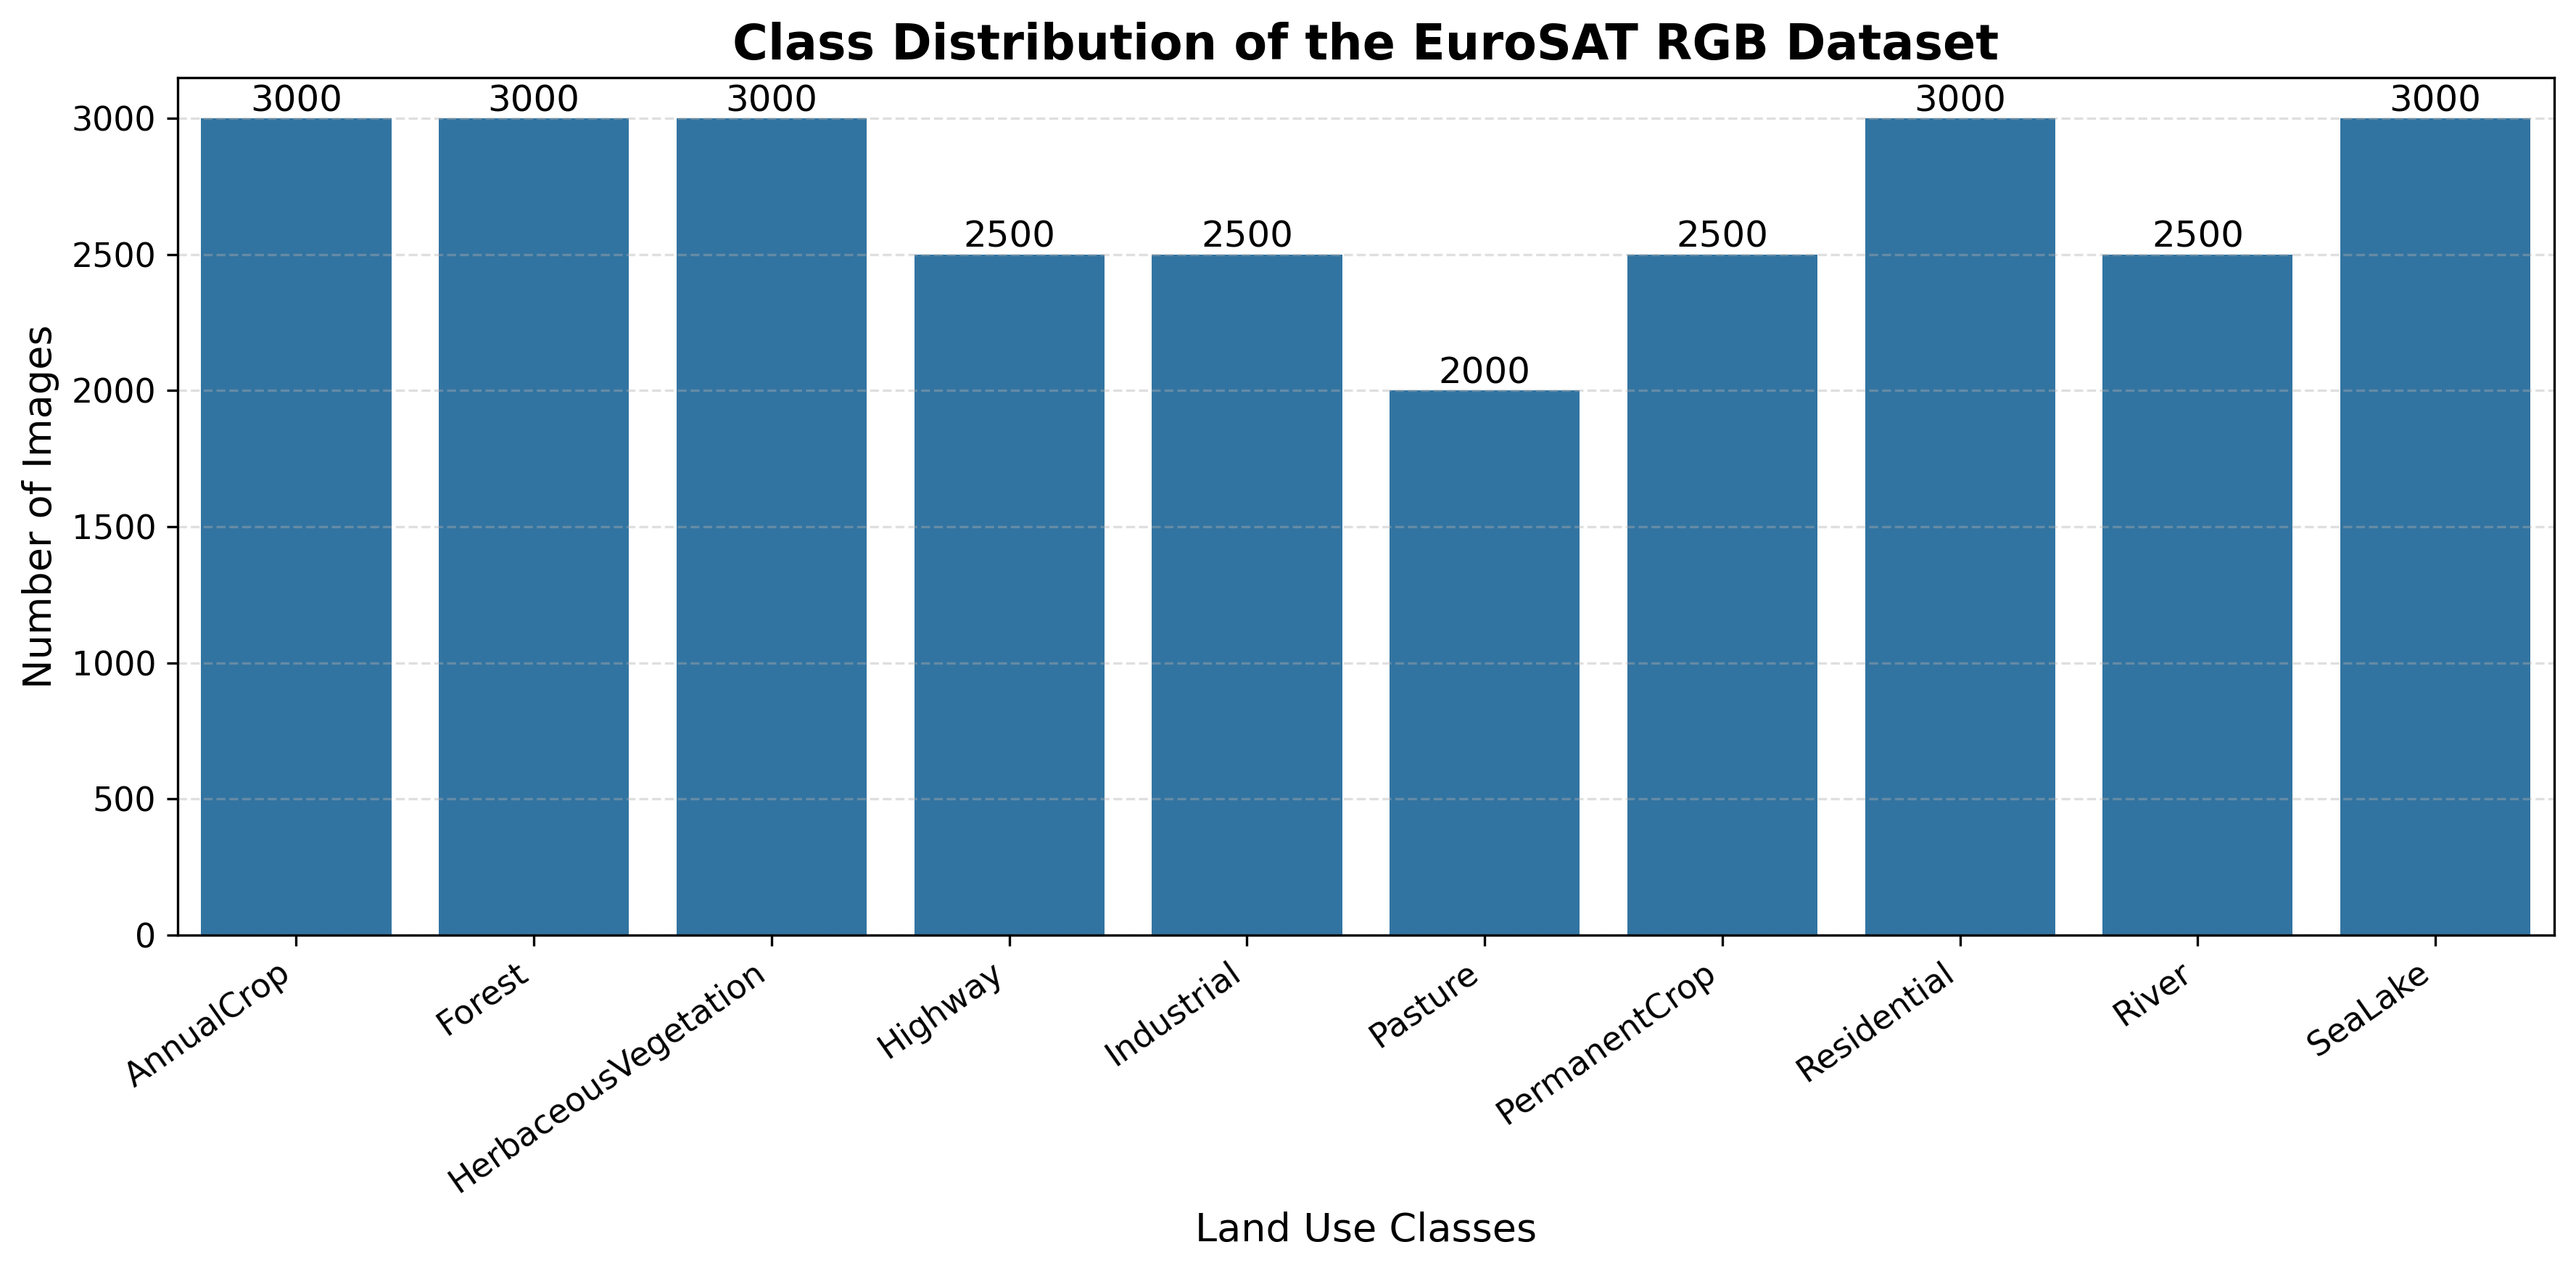

In [8]:
# ============================================================
# Step 3.3 - Publication Quality Class Distribution
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Publication style
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 300,
    "savefig.dpi": 300
})

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=dataset_summary,
    x="Class",
    y="Number of Images"
)

# Display values above each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.title("Class Distribution of the EuroSAT RGB Dataset", fontweight="bold")

plt.xlabel("Land Use Classes")

plt.ylabel("Number of Images")

plt.xticks(rotation=35, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "outputs/figures/class_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

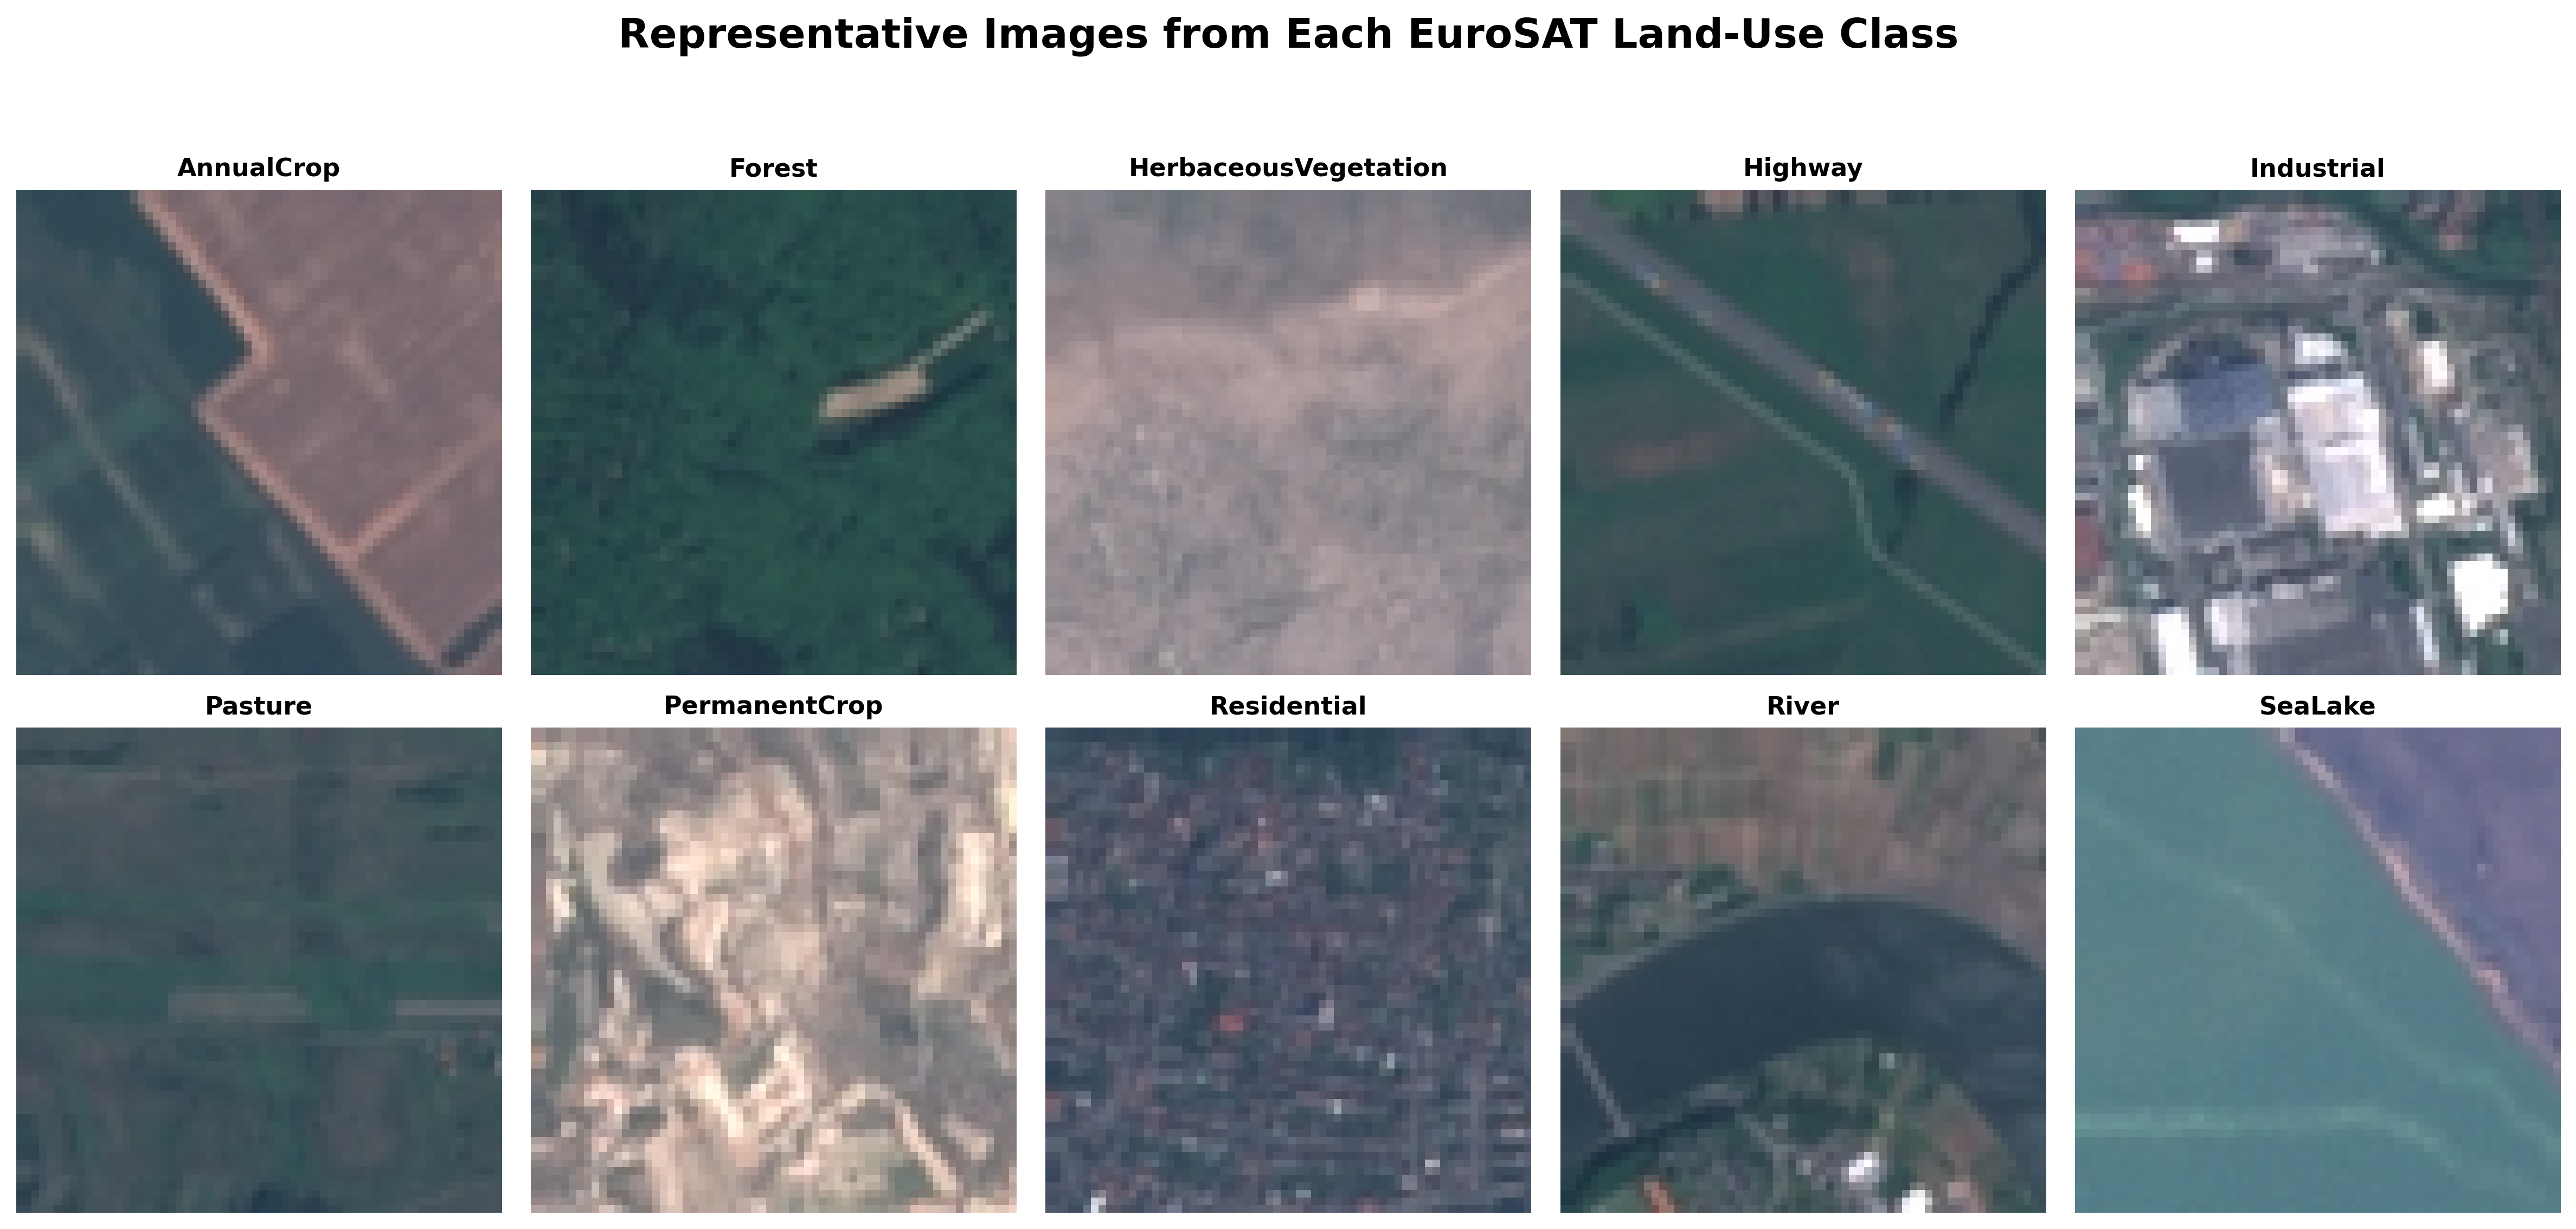

In [9]:
# ============================================================
# Step 3.4 - Display Representative Sample Images
# ============================================================

import random
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(16, 8))

axes = axes.flatten()

for i, class_name in enumerate(classes):

    class_folder = os.path.join(DATASET_PATH, class_name)

    # Select a random image
    image_name = random.choice(os.listdir(class_folder))

    image_path = os.path.join(class_folder, image_name)

    image = Image.open(image_path)

    axes[i].imshow(image)

    axes[i].set_title(class_name, fontsize=11, fontweight="bold")

    axes[i].axis("off")

plt.suptitle(
    "Representative Images from Each EuroSAT Land-Use Class",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "outputs/figures/sample_images.pdf",
    bbox_inches="tight"
)

plt.show()

In [10]:
# ============================================================
# Step 3.5 - Dataset Cleaning
# ============================================================

from PIL import Image
import os

valid_images = 0
corrupted_images = 0

corrupted_files = []

for class_name in classes:

    class_path = os.path.join(DATASET_PATH, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        try:

            img = Image.open(image_path)

            img.verify()      # Verify image integrity

            valid_images += 1

        except Exception:

            corrupted_images += 1

            corrupted_files.append(image_path)

print("=" * 60)
print("DATASET CLEANING SUMMARY")
print("=" * 60)

print(f"Valid Images      : {valid_images}")
print(f"Corrupted Images  : {corrupted_images}")

cleaning_summary = pd.DataFrame({
    "Metric": [
        "Valid Images",
        "Corrupted Images"
    ],
    "Count": [
        valid_images,
        corrupted_images
    ]
})

cleaning_summary

cleaning_summary.to_csv(
    "outputs/tables/dataset_cleaning_summary.csv",
    index=False
)

DATASET CLEANING SUMMARY
Valid Images      : 27000
Corrupted Images  : 0


# 4. Dataset Preparation

The dataset is divided into training, validation, and testing subsets to enable unbiased model evaluation. Appropriate preprocessing steps are applied to ensure consistent image dimensions, balanced data handling, and reproducible experiments.

In [11]:
# ============================================================
# Step 4.1 - Create Master Dataset
# ============================================================

image_paths = []
labels = []

for class_name in classes:

    class_folder = os.path.join(DATASET_PATH, class_name)

    for image_name in os.listdir(class_folder):

        image_path = os.path.join(class_folder, image_name)

        image_paths.append(image_path)

        labels.append(class_name)

dataset = pd.DataFrame({
    "Image_Path": image_paths,
    "Label": labels
})

print("=" * 60)
print("MASTER DATASET")
print("=" * 60)

display(dataset.head())

print(f"\nTotal Images: {len(dataset)}")

MASTER DATASET


,Image_Path,Label
0,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
1,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
2,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
3,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
4,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop



Total Images: 27000


In [12]:
# ============================================================
# Step 4.2 - Train / Validation / Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# -------------------------------
# First Split
# 70% Train
# 30% Temporary
# -------------------------------

train_df, temp_df = train_test_split(
    dataset,
    test_size=0.30,
    stratify=dataset["Label"],
    random_state=SEED
)

# -------------------------------
# Second Split
# 15% Validation
# 15% Test
# -------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Label"],
    random_state=SEED
)

print("="*60)
print("DATASET SPLIT SUMMARY")
print("="*60)

print(f"Training Images   : {len(train_df)}")
print(f"Validation Images : {len(val_df)}")
print(f"Testing Images    : {len(test_df)}")

DATASET SPLIT SUMMARY
Training Images   : 18900
Validation Images : 4050
Testing Images    : 4050


In [13]:
# ============================================================
# Step 4.3 - Verify Dataset Split
# ============================================================

split_summary = pd.DataFrame({
    "Training": train_df["Label"].value_counts().sort_index(),
    "Validation": val_df["Label"].value_counts().sort_index(),
    "Testing": test_df["Label"].value_counts().sort_index()
})

split_summary.index.name = "Class"

display(split_summary)

split_summary.to_csv(
    "outputs/tables/dataset_split_verification.csv"
)

print("Dataset split verification saved successfully.")

split_summary.to_csv(
    "outputs/tables/dataset_split_summary.csv"
)

print("Dataset splits saved successfully.")

,Training,Validation,Testing
Class,,,
AnnualCrop,2100,450,450
Forest,2100,450,450
HerbaceousVegetation,2100,450,450
Highway,1750,375,375
Industrial,1750,375,375
Pasture,1400,300,300
PermanentCrop,1750,375,375
Residential,2100,450,450
River,1750,375,375


Dataset split verification saved successfully.
Dataset splits saved successfully.


# 5. Data Preprocessing

Before training, all satellite images are resized and normalized to a consistent input size suitable for deep learning models. These preprocessing steps improve numerical stability during optimization and ensure compatibility with both the custom CNN and transfer learning architectures.

In [14]:
# ============================================================
# Step 5.1 - Encode Class Labels
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["Label_Encoded"] = label_encoder.fit_transform(
    train_df["Label"]
)

val_df["Label_Encoded"] = label_encoder.transform(
    val_df["Label"]
)

test_df["Label_Encoded"] = label_encoder.transform(
    test_df["Label"]
)

print("=" * 60)
print("CLASS LABEL MAPPING")
print("=" * 60)

for index, label in enumerate(label_encoder.classes_):
    print(f"{index} -> {label}")

CLASS LABEL MAPPING
0 -> AnnualCrop
1 -> Forest
2 -> HerbaceousVegetation
3 -> Highway
4 -> Industrial
5 -> Pasture
6 -> PermanentCrop
7 -> Residential
8 -> River
9 -> SeaLake


In [15]:
mapping = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Encoded_Label": range(len(label_encoder.classes_))
})

display(mapping)

mapping.to_csv(
    "outputs/tables/class_label_mapping.csv",
    index=False
)

class_names = list(label_encoder.classes_)

,Class,Encoded_Label
0,AnnualCrop,0
1,Forest,1
2,HerbaceousVegetation,2
3,Highway,3
4,Industrial,4
5,Pasture,5
6,PermanentCrop,6
7,Residential,7
8,River,8
9,SeaLake,9


In [16]:
# ============================================================
# Step 5.2 - Image Loading Function
# ============================================================

def load_image(image_path, label):
    """
    Reads an image from disk, resizes it,
    and normalizes pixel values.
    """

    # Read image
    image = tf.io.read_file(image_path)

    # Decode JPEG image
    image = tf.image.decode_jpeg(image, channels=3)

    # Resize image
    image = tf.image.resize(image, IMAGE_SIZE)

    # Normalize pixel values to [0,1]
    image = image / 255.0

    return image, label

In [17]:
# ============================================================
# Step 5.3 - Convert DataFrames to TensorFlow Datasets
# ============================================================

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["Image_Path"].values,
        train_df["Label_Encoded"].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["Image_Path"].values,
        val_df["Label_Encoded"].values
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["Image_Path"].values,
        test_df["Label_Encoded"].values
    )
)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


I0000 00:00:1782633933.789223      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782633933.795313      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [18]:
# ============================================================
# Step 5.4 - Apply Image Loading Function
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

print("Images loaded successfully.")

Images loaded successfully.


In [19]:
# ============================================================
# Step 5.5 - Batch and Prefetch
# ============================================================

train_dataset = (
    train_dataset
    .shuffle(1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("TensorFlow pipeline is ready.")

TensorFlow pipeline is ready.


In [20]:
# ============================================================
# Step 5.6 - Verify the Pipeline
# ============================================================

for images, labels in train_dataset.take(1):

    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

    print("\nPixel Value Range:")
    print(f"Minimum: {tf.reduce_min(images):.3f}")
    print(f"Maximum: {tf.reduce_max(images):.3f}")

Image Batch Shape : (32, 64, 64, 3)
Label Batch Shape : (32,)

Pixel Value Range:
Minimum: 0.075
Maximum: 1.000


# 6. Data Augmentation

Data augmentation is employed to artificially increase the diversity of the training dataset. Random transformations such as flipping, rotation, zooming, and translation improve the model's ability to generalize by reducing overfitting and increasing robustness to variations in satellite imagery.

In [21]:
# ============================================================
# Step 6.1 - Data Augmentation Layer
# ============================================================

data_augmentation = tf.keras.Sequential([
    
    tf.keras.layers.RandomFlip(
        mode="horizontal_and_vertical"
    ),

    tf.keras.layers.RandomRotation(
        factor=0.10
    ),

    tf.keras.layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    )

], name="Data_Augmentation")

print("Data augmentation layer created successfully.")

Data augmentation layer created successfully.


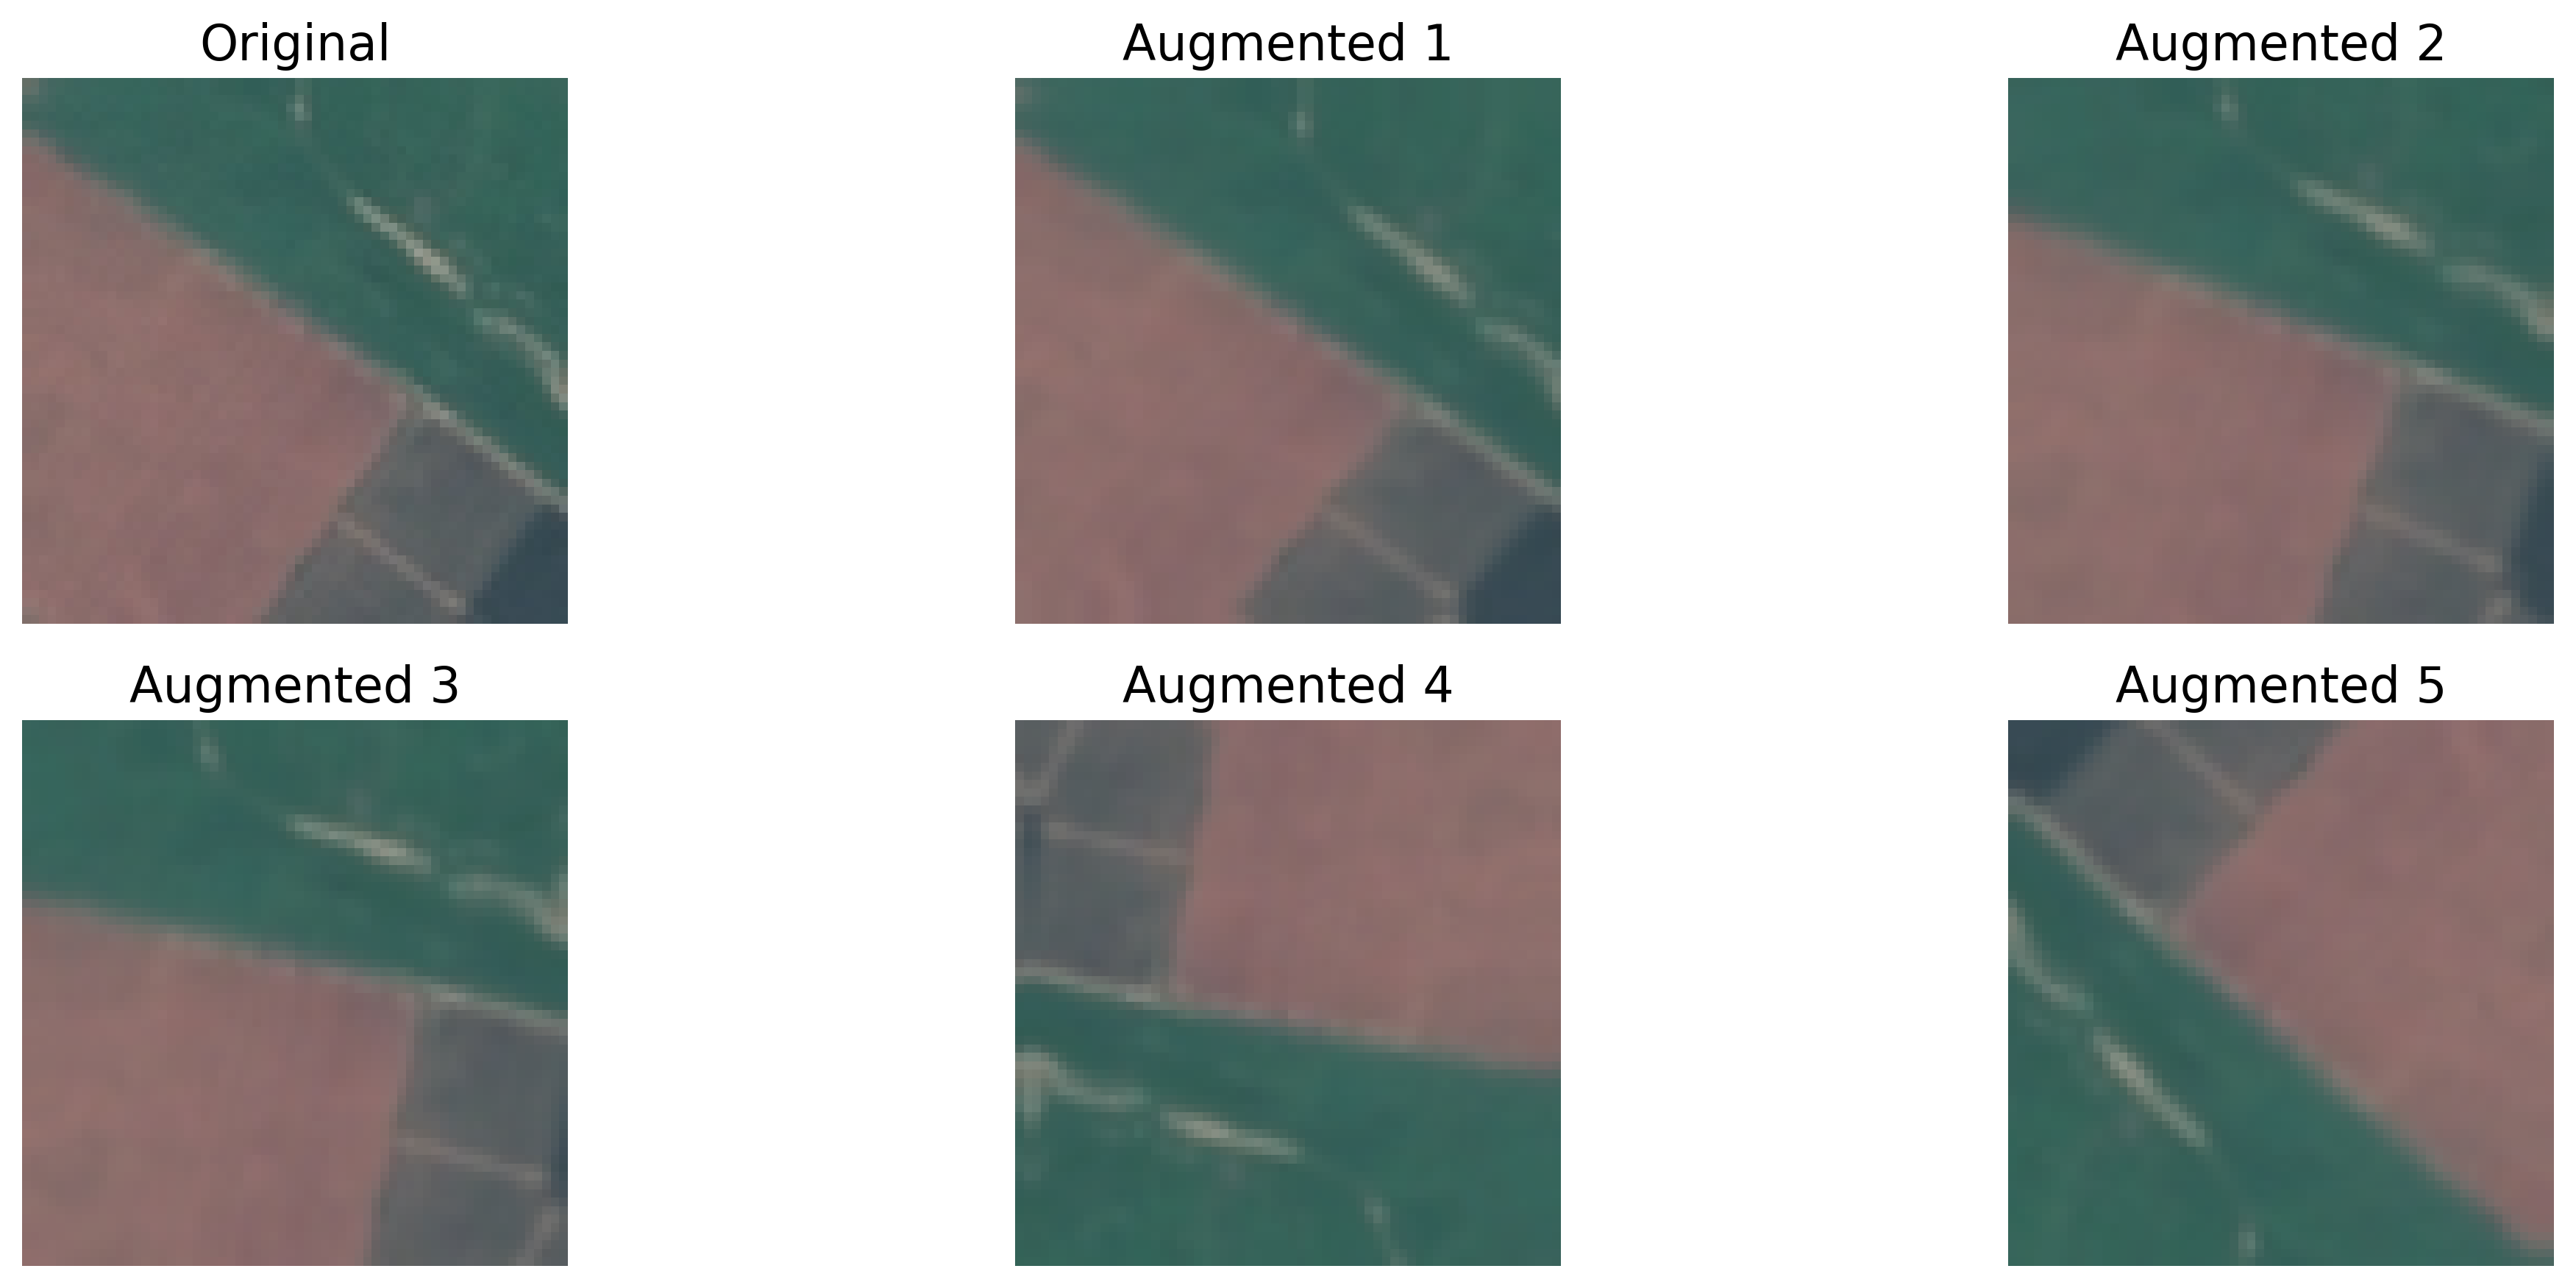

In [22]:
# ============================================================
# Step 6.2 - Visualize Data Augmentation
# ============================================================

import matplotlib.pyplot as plt

# Get one batch
sample_images, sample_labels = next(iter(train_dataset))

# Select first image
original_image = sample_images[0]

# Generate augmented versions
augmented_images = [
    data_augmentation(tf.expand_dims(original_image, axis=0), training=True)[0]
    for _ in range(5)
]

# Plot
plt.figure(figsize=(15, 6))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

# Augmented images
for i, aug_image in enumerate(augmented_images, start=2):
    plt.subplot(2, 3, i)
    plt.imshow(aug_image)
    plt.title(f"Augmented {i-1}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "outputs/figures/data_augmentation_examples.pdf",
    bbox_inches="tight"
)

plt.show()

# 7. Custom CNN Model

A custom Convolutional Neural Network (CNN) is developed from scratch to establish a baseline for satellite image classification. The architecture consists of multiple convolutional, pooling, normalization, and fully connected layers designed to learn discriminative spatial features directly from the EuroSAT RGB dataset.

In [23]:
# ============================================================
# Step 7.1 - Build Custom CNN
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

custom_cnn_model = Sequential([

    # Input Layer
    Input(shape=(64, 64, 3)),

    # Data Augmentation
    data_augmentation,

    # -----------------------------
    # Convolution Block 1
    # -----------------------------
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),

    # -----------------------------
    # Convolution Block 2
    # -----------------------------
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),

    # -----------------------------
    # Convolution Block 3
    # -----------------------------
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),

    # Fully Connected Layers
    Flatten(),

    Dense(
        units=256,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        units=NUM_CLASSES,
        activation="softmax"
    )

])

print("Custom CNN created successfully.")

Custom CNN created successfully.


In [24]:
# ============================================================
# Step 7.2 - Model Summary
# ============================================================

custom_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Data_Augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,194,122 (8.37 MB)

 Trainable params: 2,193,674 (8.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [25]:
# ============================================================
# Step 7.3 - Compile Custom CNN
# ============================================================

custom_cnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

print("Model compiled successfully.")

Model compiled successfully.


In [26]:
# ============================================================
# Step 7.4 - Training Callbacks
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1
)

model_checkpoint = ModelCheckpoint(

    filepath="models/custom_cnn_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1
)

callbacks = [

    early_stopping,

    model_checkpoint,

    reduce_lr

]

print("Callbacks configured successfully.")

Callbacks configured successfully.


In [27]:
# ============================================================
# Step 7.5 - Train Custom CNN
# ============================================================

import time

start_time = time.time()

history = custom_cnn_model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1

)

training_time = time.time() - start_time

print("\nTraining completed successfully.")

print(f"\nTotal Training Time: {training_time:.2f} seconds")

# ============================================================
# Save Training History
# ============================================================

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "outputs/tables/custom_cnn_training_history.csv",
    index=False
)

print("Training history saved.")

Epoch 1/30


I0000 00:00:1782633943.057902     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4375 - loss: 2.0876
Epoch 1: val_accuracy improved from None to 0.57235, saving model to models/custom_cnn_best.keras

Epoch 1: finished saving model to models/custom_cnn_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.4982 - loss: 1.5249 - val_accuracy: 0.5723 - val_loss: 1.4267 - learning_rate: 0.0010
Epoch 2/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5814 - loss: 1.1839
Epoch 2: val_accuracy improved from 0.57235 to 0.64815, saving model to models/custom_cnn_best.keras

Epoch 2: finished saving model to models/custom_cnn_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6001 - loss: 1.1293 - val_accuracy: 0.6481 - val_loss: 1.1843 - learning_rate: 0.0010
Epoch 3/30
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6289 - loss: 1.0495
Epoch 3: val_accuracy did not improve from 0.64815
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6440 - loss: 1.0144 - val_acc

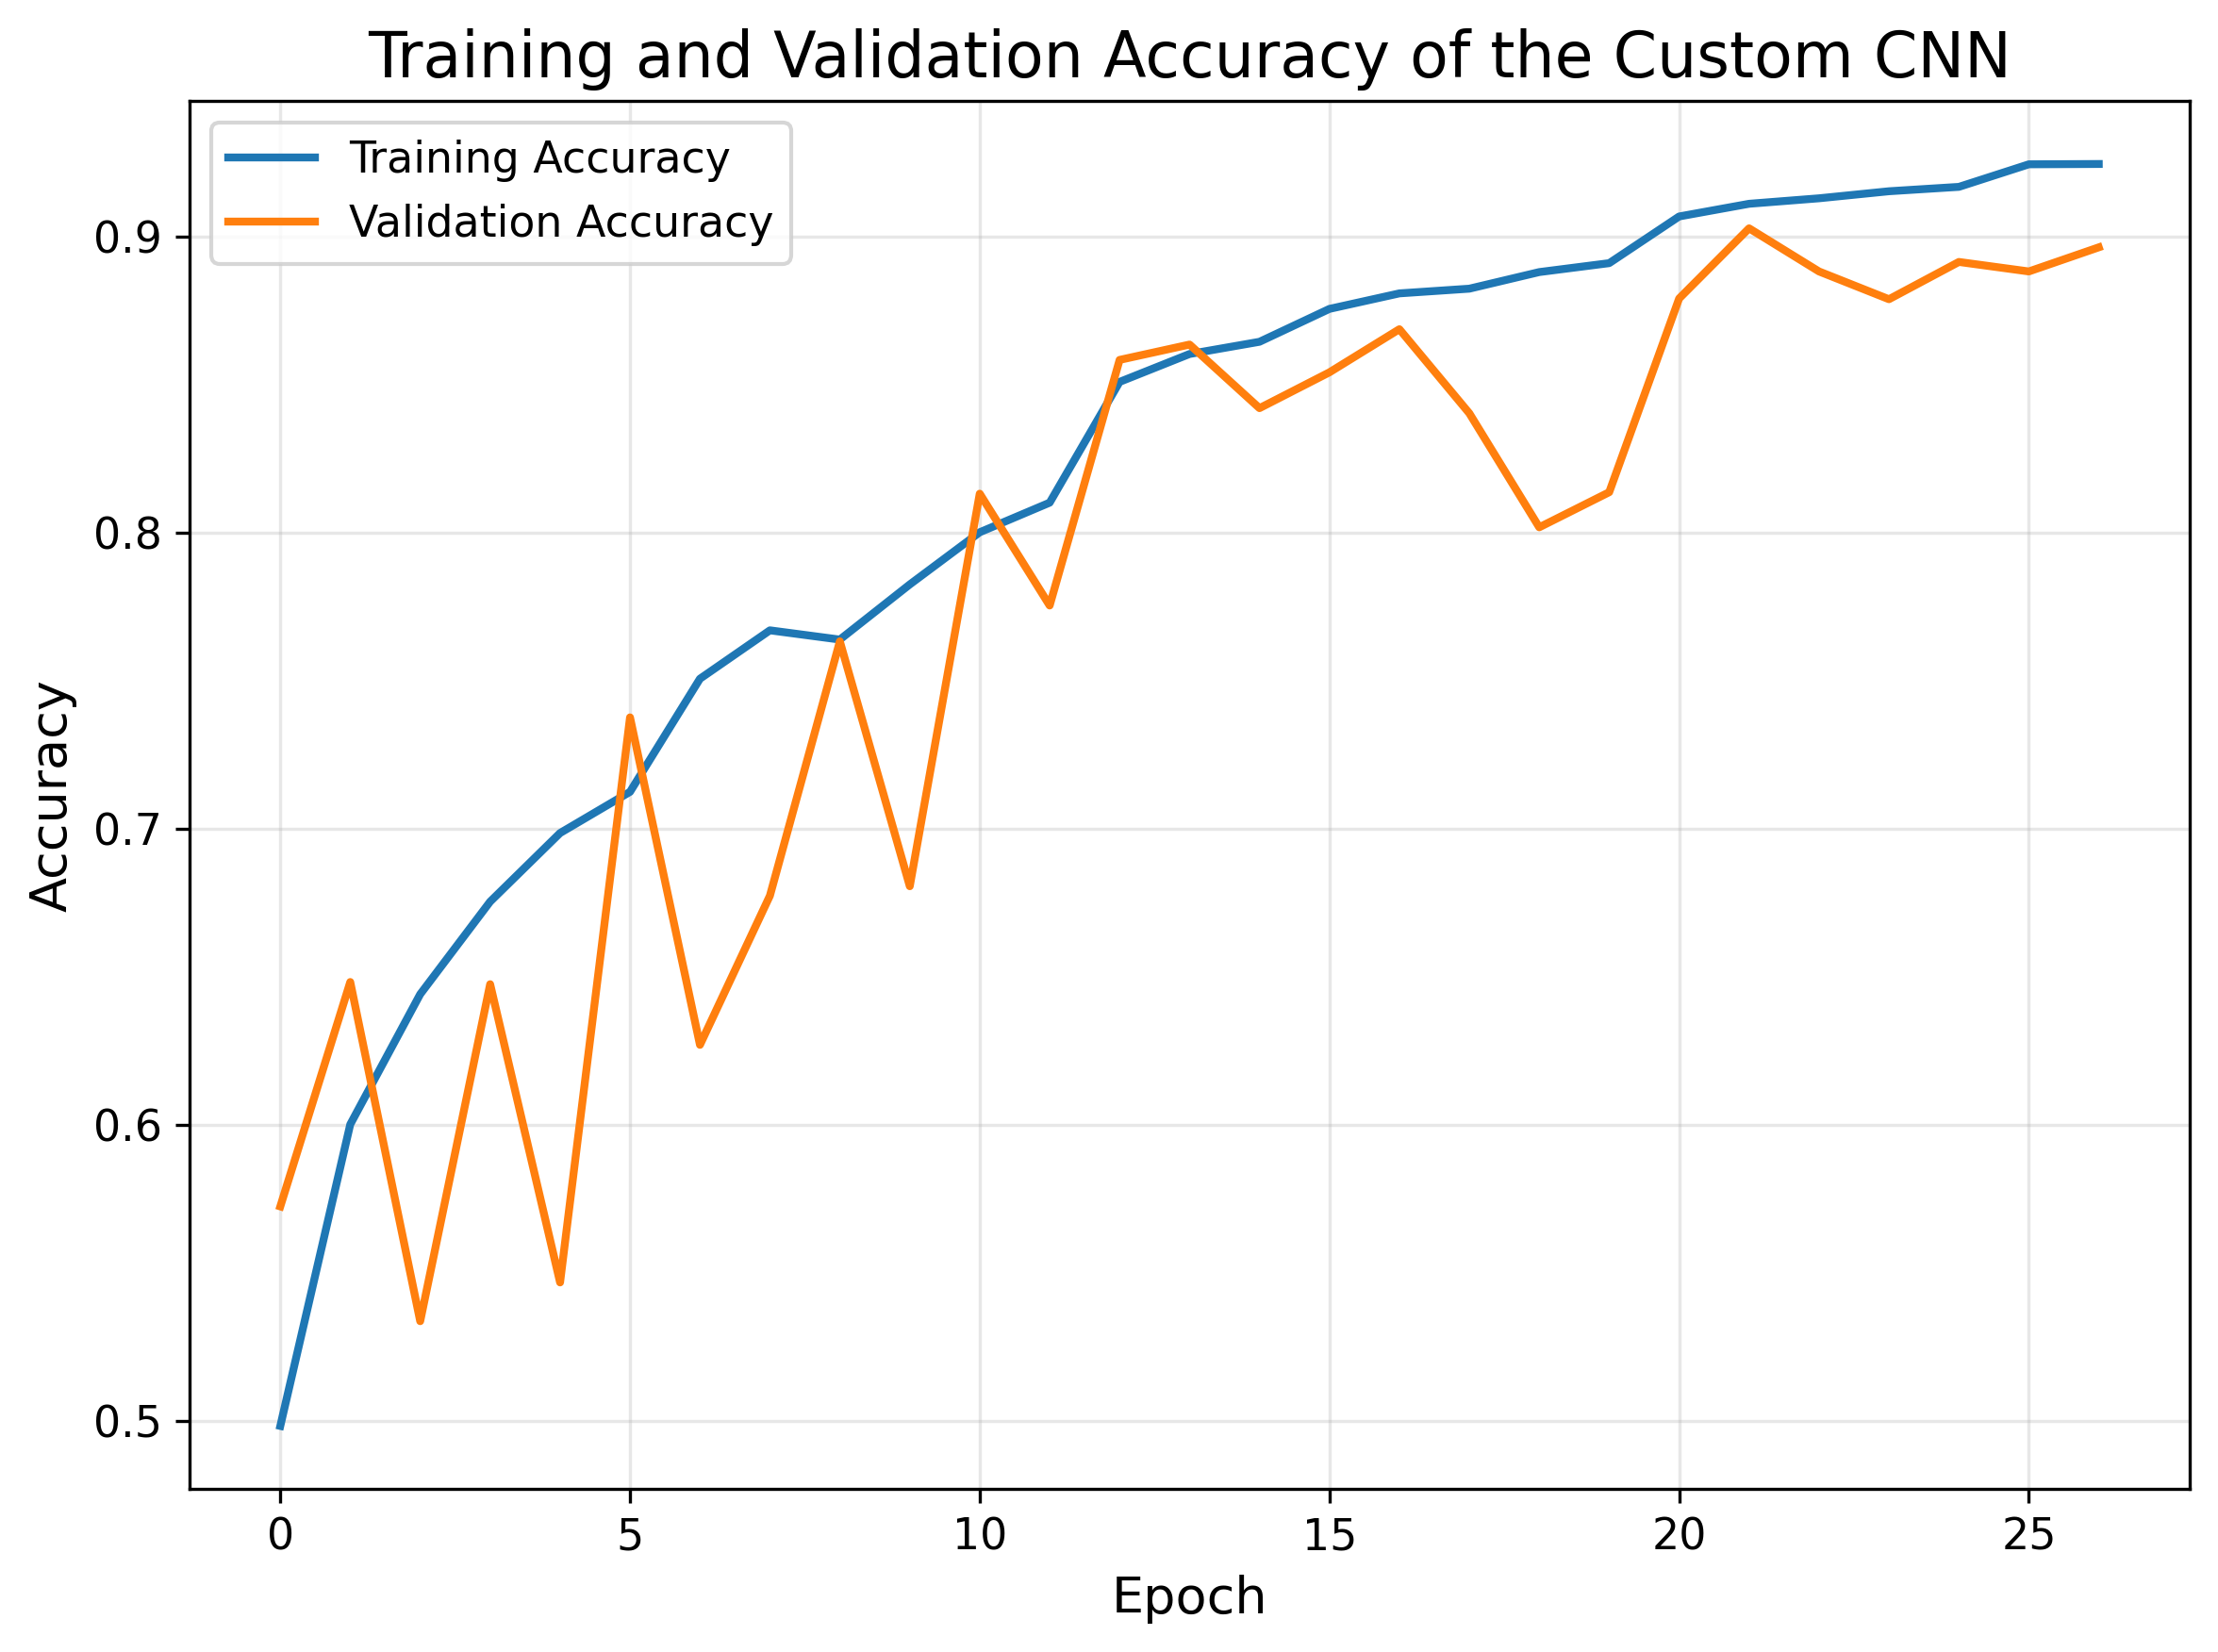

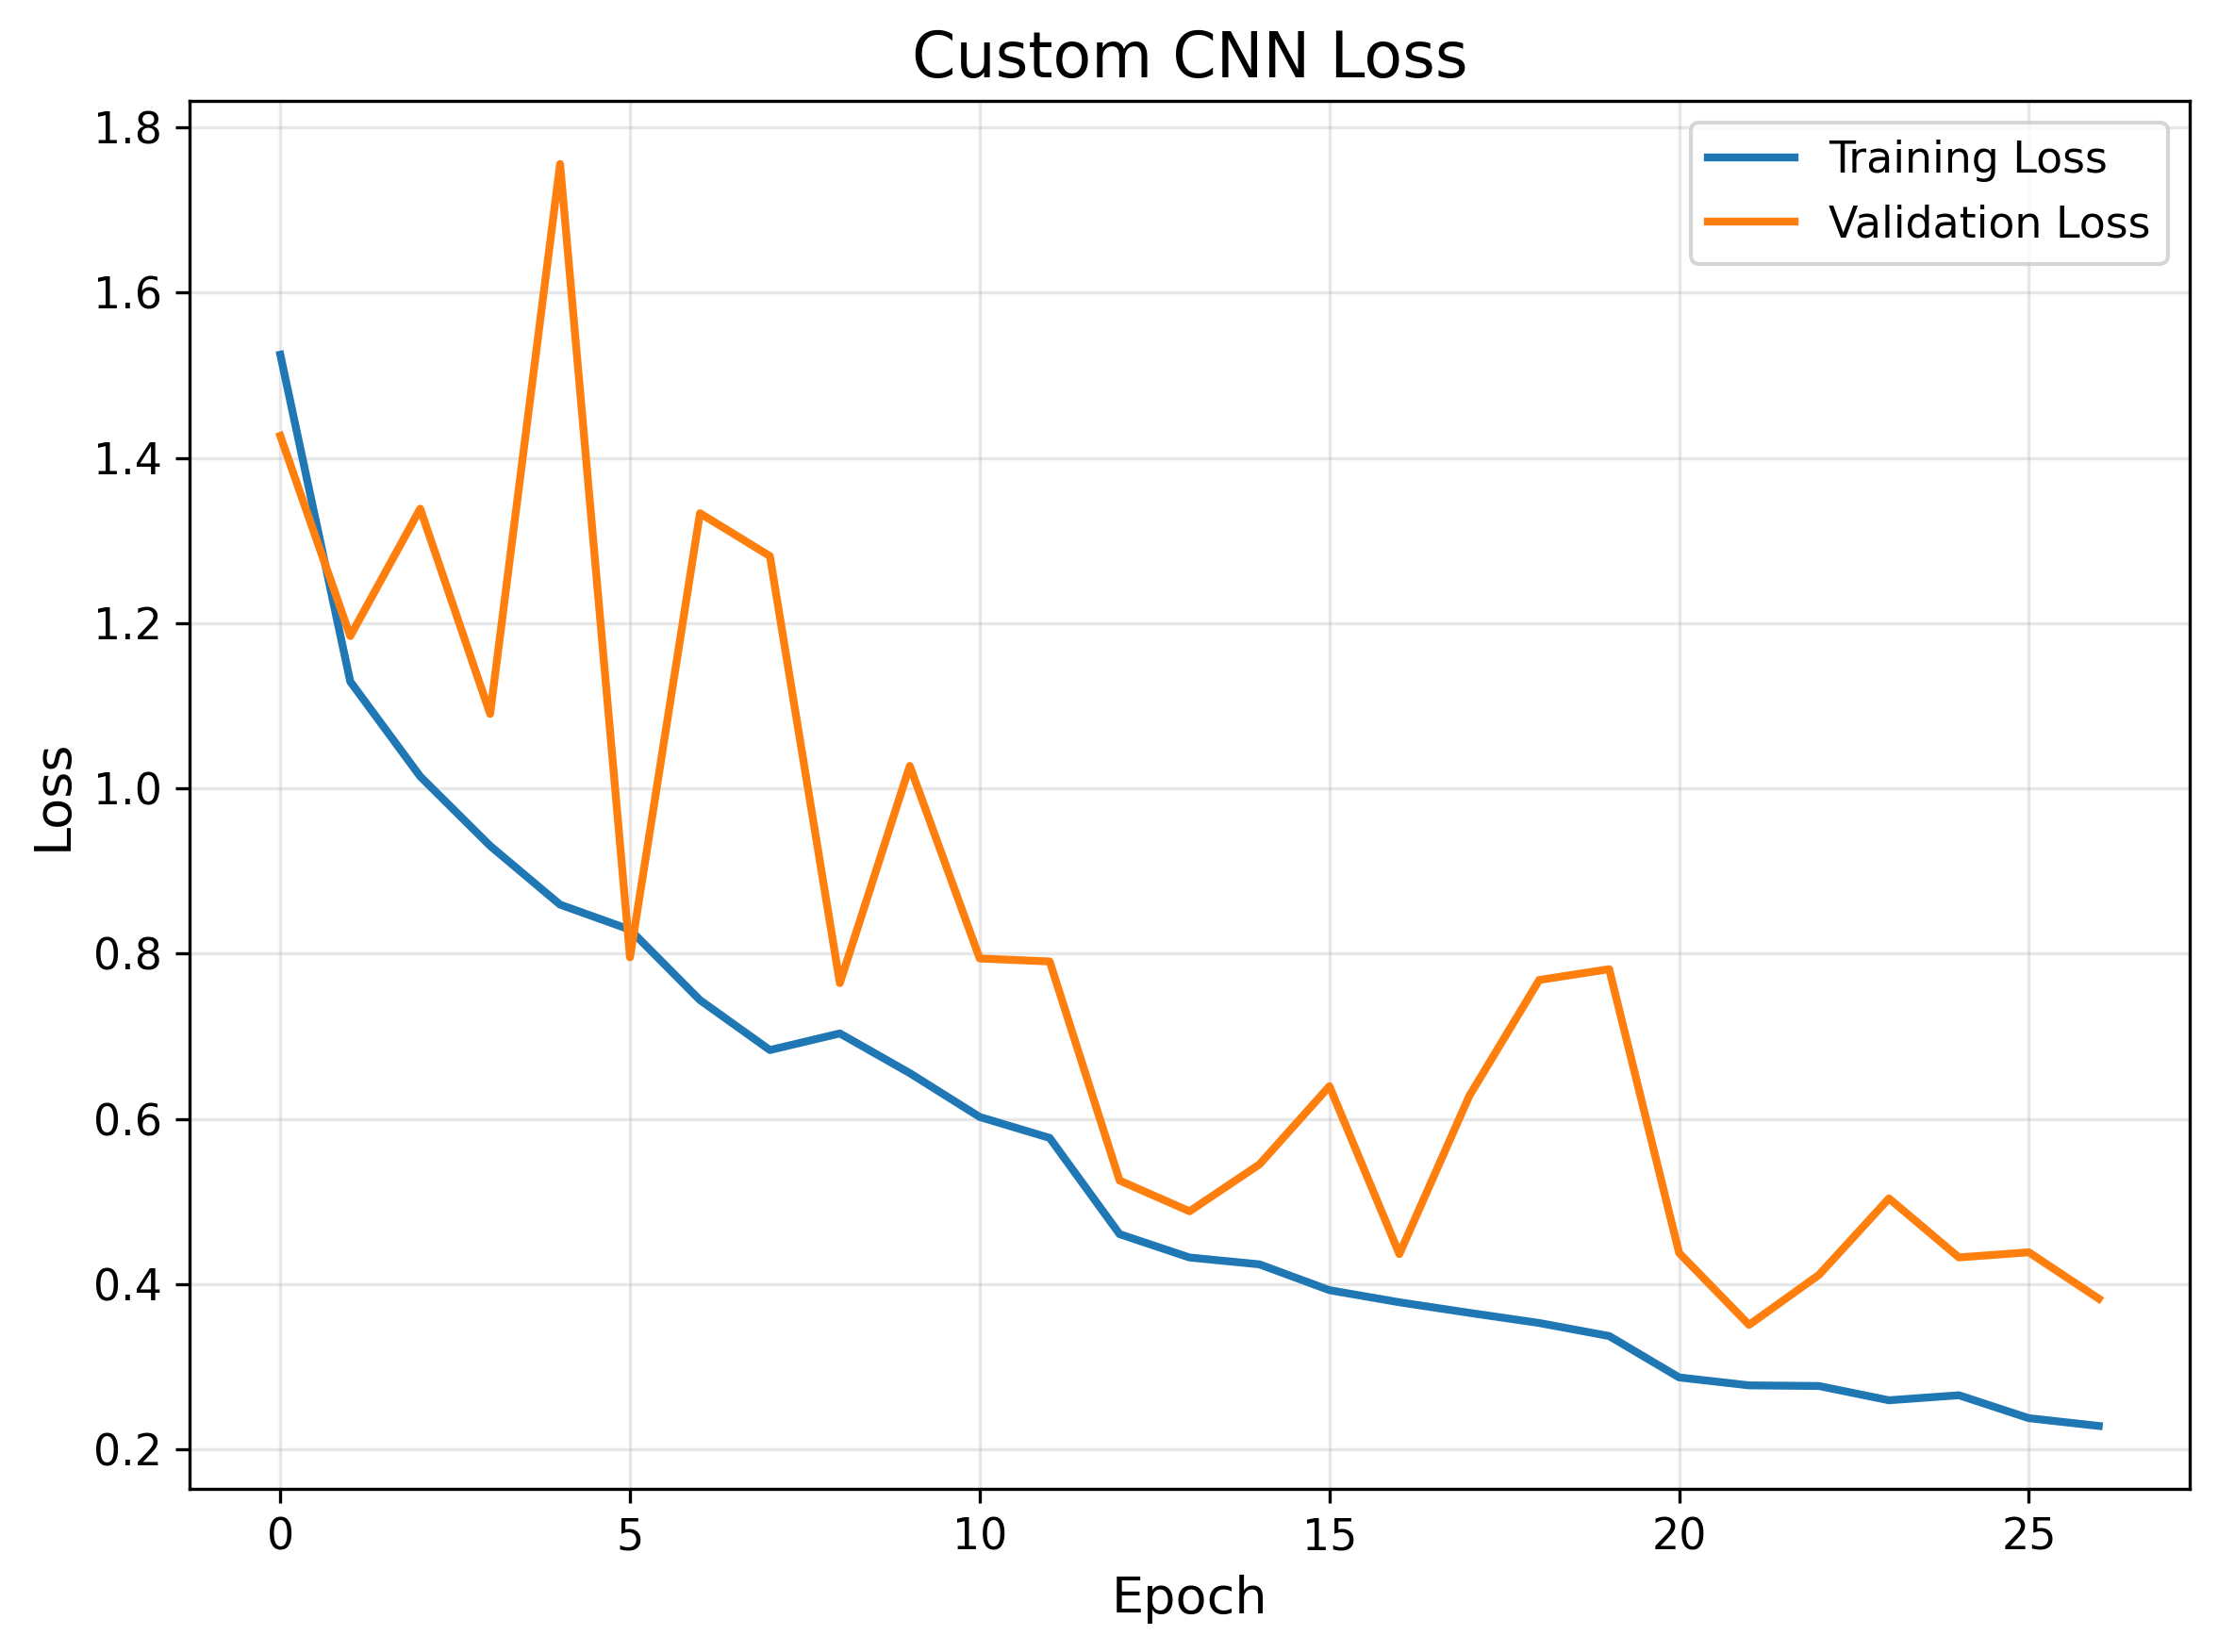

In [28]:
# ============================================================
# Step 7.6 - Training Curves
# ============================================================

import matplotlib.pyplot as plt

# -----------------------------
# Accuracy
# -----------------------------

plt.figure(figsize=(8,6))

plt.plot(
    history.history["accuracy"],
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy of the Custom CNN")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "outputs/figures/custom_cnn_accuracy.pdf",
    bbox_inches="tight"
)

plt.show()

# -----------------------------
# Loss
# -----------------------------

plt.figure(figsize=(8,6))

plt.plot(
    history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.title("Custom CNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "outputs/figures/custom_cnn_loss.pdf",
    bbox_inches="tight"
)

plt.show()

In [29]:
# ============================================================
# Step 7.7 - Test Evaluation
# ============================================================

test_loss, test_accuracy = custom_cnn_model.evaluate(
    test_dataset,
    verbose=1
)

print("="*60)
print("CUSTOM CNN TEST PERFORMANCE")
print("="*60)

print(f"Test Accuracy : {test_accuracy:.4f}")

print(f"Test Loss     : {test_loss:.4f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8970 - loss: 0.3519
CUSTOM CNN TEST PERFORMANCE
Test Accuracy : 0.8970
Test Loss     : 0.3519


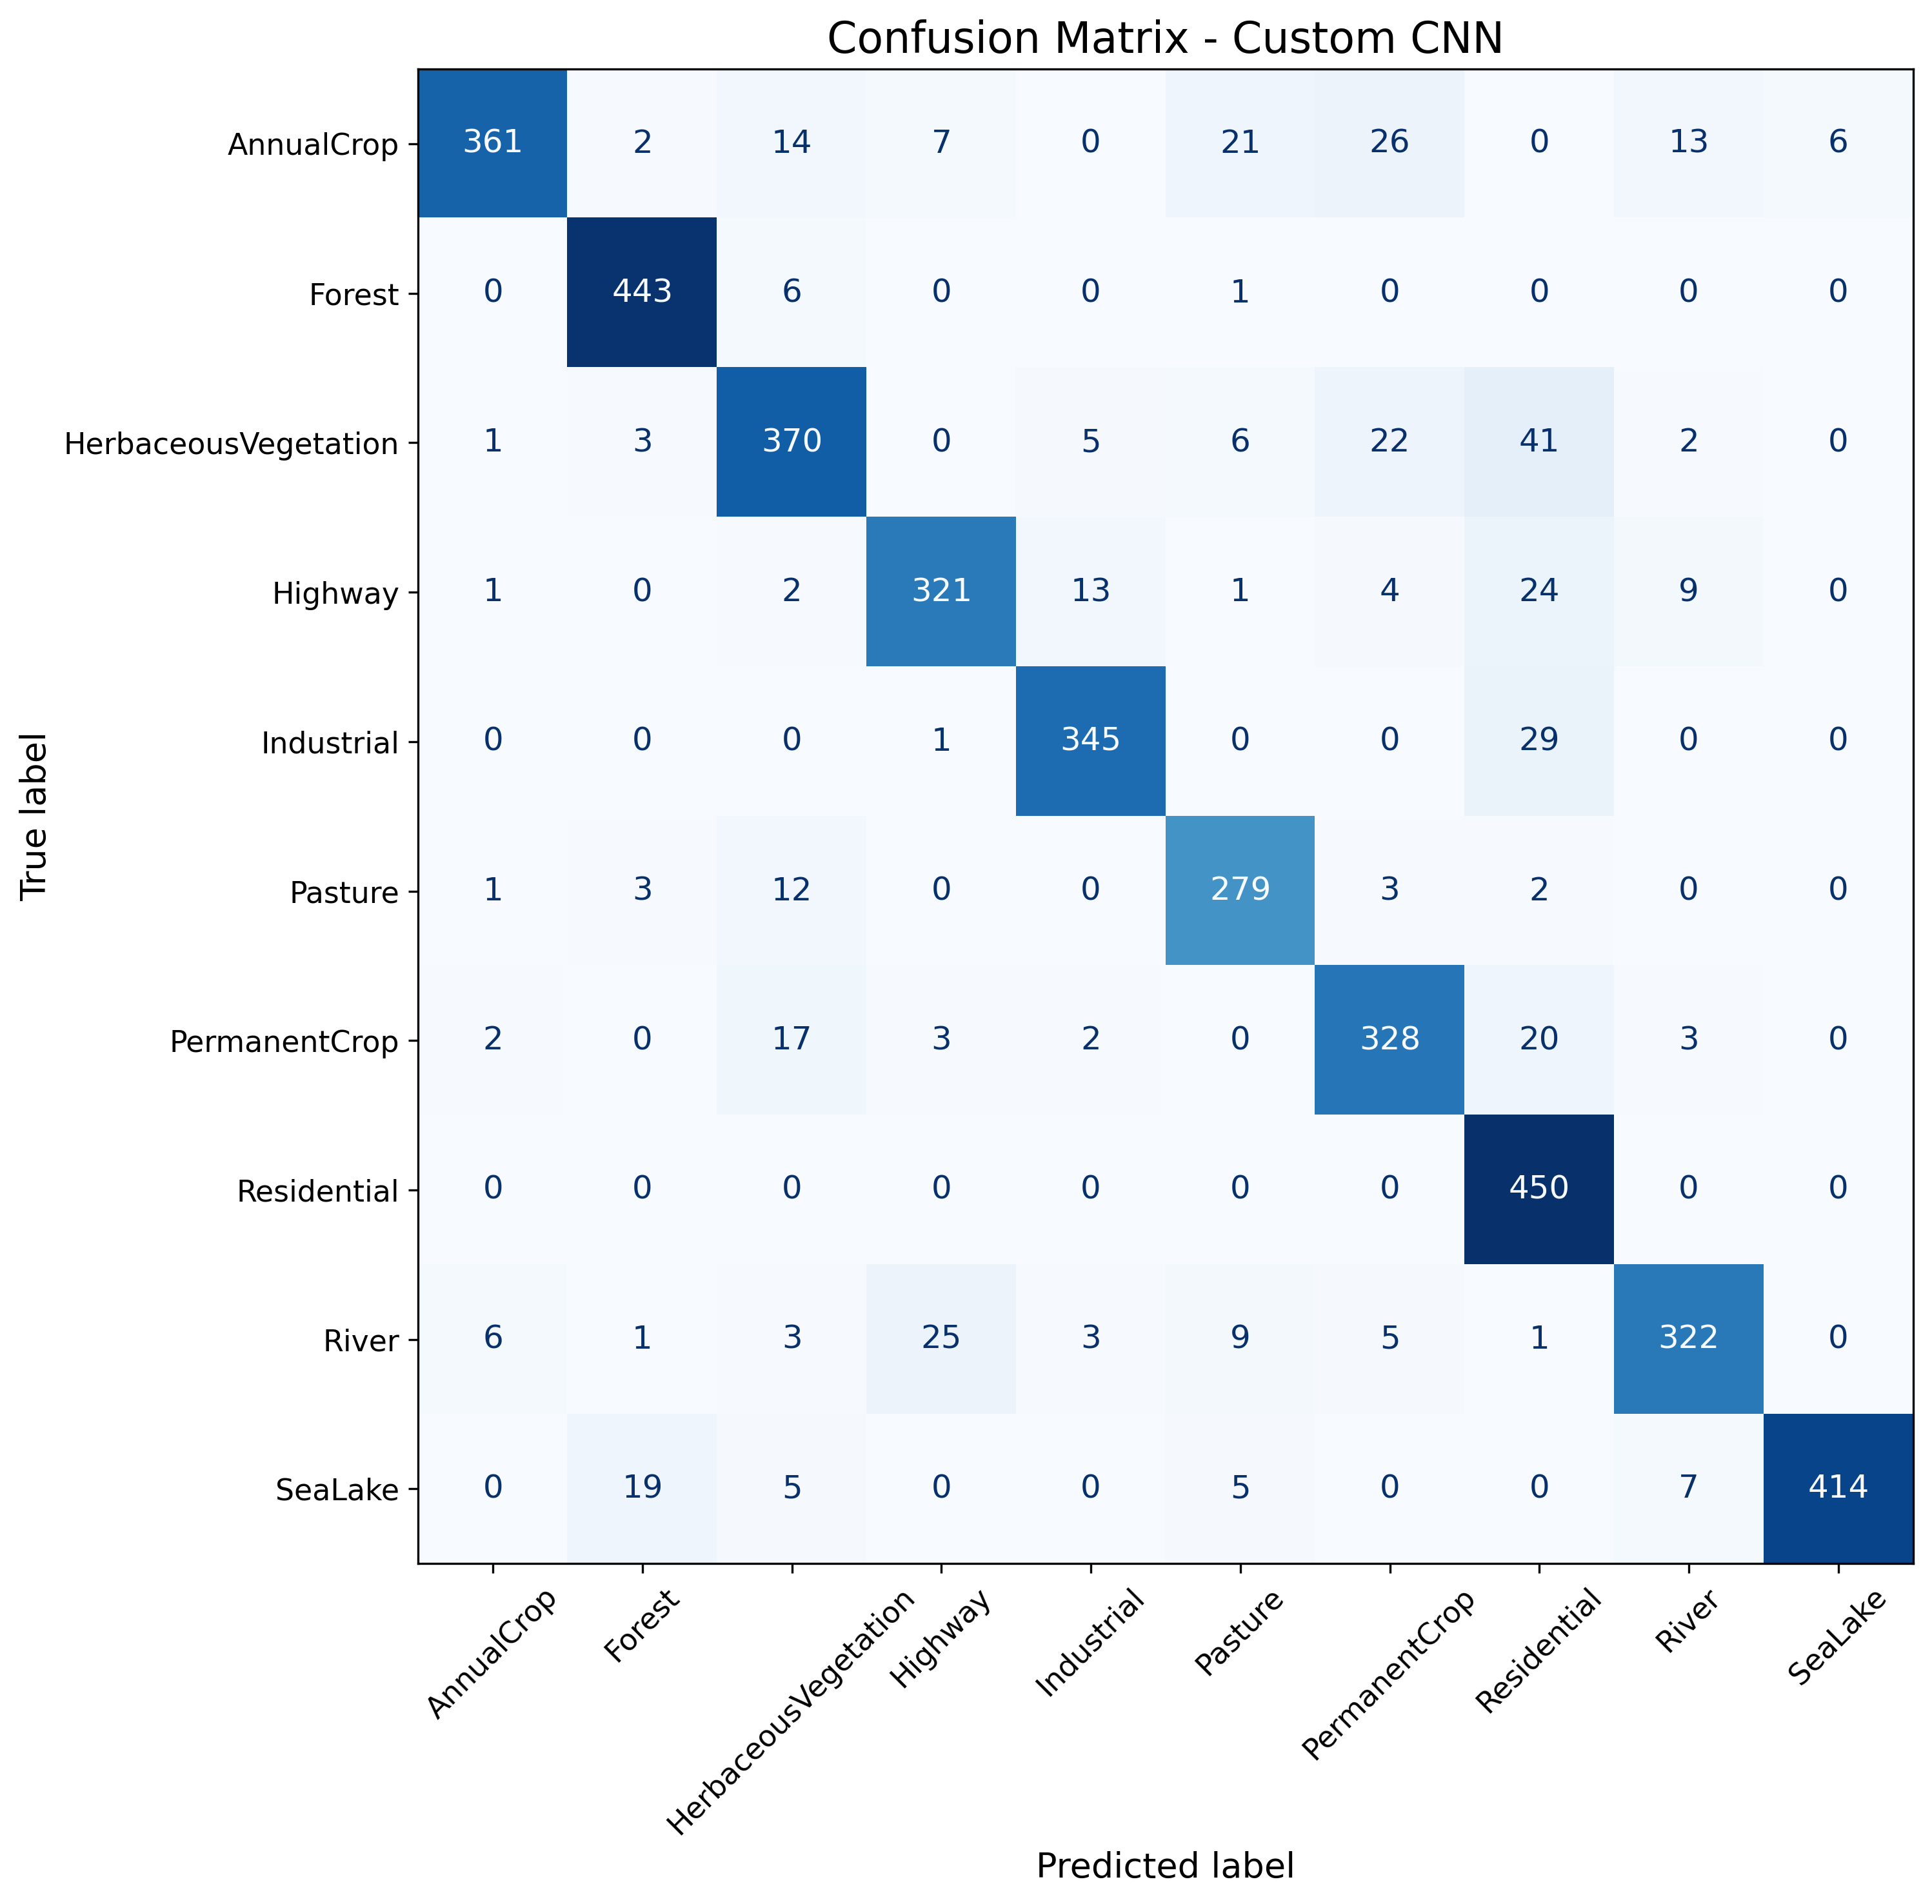

In [30]:
# ============================================================
# Step 7.8 - Predictions & Confusion Matrix
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------
# Generate Predictions
# -----------------------------

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = custom_cnn_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# -----------------------------
# Confusion Matrix
# -----------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(figsize=(11,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title(
    "Confusion Matrix - Custom CNN",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "outputs/confusion_matrices/custom_cnn_confusion_matrix.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
# ============================================================
# Step 7.9 - Classification Report
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True\
)

report_df = pd.DataFrame(report).transpose()

report_df = report_df.round(4)

display(report_df)

report_df.to_csv(
    "outputs/tables/custom_cnn_classification_report.csv",
    index=True
)

print("Classification report saved successfully.")

,precision,recall,f1-score,support
AnnualCrop,0.9704,0.8022,0.8783,450.000
Forest,0.9406,0.9844,0.9620,450.000
HerbaceousVegetation,0.8625,0.8222,0.8419,450.000
Highway,0.8992,0.8560,0.8770,375.000
Industrial,0.9375,0.9200,0.9287,375.000
Pasture,0.8665,0.9300,0.8971,300.000
PermanentCrop,0.8454,0.8747,0.8598,375.000
Residential,0.7937,1.0000,0.8850,450.000
River,0.9045,0.8587,0.8810,375.000
SeaLake,0.9857,0.9200,0.9517,450.000


Classification report saved successfully.


In [32]:
# ============================================================
# Step 7.10 - Model Comparison Table
# ============================================================

comparison_results = pd.DataFrame({

    "Model":[
        "Custom CNN"
    ],

    "Training Accuracy (%)":[
        history.history["accuracy"][-1]*100
    ],

    "Validation Accuracy (%)":[
        history.history["val_accuracy"][-1]*100
    ],

    "Test Accuracy (%)":[
        test_accuracy*100
    ],

    "Test Loss":[
        test_loss
    ],

    "Training Time (s)":[
        training_time
    ],

    "Parameters":[
        custom_cnn_model.count_params()
    ]

})

comparison_results = comparison_results.round(2)

display(comparison_results)

comparison_results.to_csv(
    "outputs/tables/model_comparison.csv",
    index=False
)

,Model,Training Accuracy (%),Validation Accuracy (%),Test Accuracy (%),Test Loss,Training Time (s),Parameters
0,Custom CNN,92.44,89.63,89.7,0.35,286.47,2194122


In [33]:
# ============================================================
# Section 7A - Experimental Configuration
# ============================================================

import pandas as pd
import tensorflow as tf

# Detect GPU(s)
gpu_devices = tf.config.list_physical_devices("GPU")

if len(gpu_devices) > 0:
    hardware = f"NVIDIA Tesla T4 ({len(gpu_devices)} GPU{'s' if len(gpu_devices) > 1 else ''})"
else:
    hardware = "CPU"

experiment_settings = pd.DataFrame({

    "Parameter": [
        "Dataset",
        "Number of Classes",
        "Image Size",
        "Batch Size",
        "Training Epochs",
        "Optimizer",
        "Initial Learning Rate",
        "Loss Function",
        "Evaluation Metrics",
        "Framework",
        "TensorFlow Version",
        "Hardware"
    ],

    "Value": [
        "EuroSAT RGB",
        NUM_CLASSES,
        f"{IMAGE_SIZE[0]} × {IMAGE_SIZE[1]}",
        BATCH_SIZE,
        EPOCHS,
        "Adam",
        0.001,
        "Sparse Categorical Crossentropy",
        "Accuracy, Precision, Recall, F1-score",
        "TensorFlow / Keras",
        tf.__version__,
        hardware
    ]

})

display(experiment_settings)

# Save for report
experiment_settings.to_csv(
    "outputs/tables/experimental_configuration.csv",
    index=False
)

print("Experimental configuration saved successfully.")

,Parameter,Value
0,Dataset,EuroSAT RGB
1,Number of Classes,10
2,Image Size,64 × 64
3,Batch Size,32
4,Training Epochs,30
5,Optimizer,Adam
6,Initial Learning Rate,0.001
7,Loss Function,Sparse Categorical Crossentropy
8,Evaluation Metrics,"Accuracy, Precision, Recall, F1-score"
9,Framework,TensorFlow / Keras


Experimental configuration saved successfully.


# 8. MobileNetV2 Transfer Learning

MobileNetV2 is employed as the first transfer learning model. Pre-trained ImageNet weights are utilized to leverage previously learned visual representations while fine-tuning the classifier for satellite land-use classification. This lightweight architecture provides an efficient balance between computational cost and classification performance.

In [34]:
# ============================================================
# Step 8.1 - Build MobileNetV2
# ============================================================

import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.layers import (
    Input,
    Lambda,
    Rescaling,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

# --------------------------------------------------
# Load ImageNet Pretrained Model
# --------------------------------------------------

base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(64,64,3)

)

# Freeze backbone
base_model.trainable = False

# --------------------------------------------------
# Build Complete Model
# --------------------------------------------------

inputs = Input(shape=(64,64,3))

# Existing augmentation
x = data_augmentation(inputs)

# Convert [0,1] → [0,255]
x = Rescaling(255.0, name="restore_pixel_range")(x)

# ImageNet preprocessing
x = Lambda(
    preprocess_input,
    name="mobilenet_preprocessing"
)(x)

# Feature extractor
x = base_model(x, training=False)

# Classification Head
x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

mobilenet_model = Model(

    inputs,

    outputs,

    name="MobileNetV2"

)

print("MobileNetV2 created successfully.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 created successfully.


In [35]:
# ============================================================
# Step 8.2 - Model Summary
# ============================================================

mobilenet_model.summary()

Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Data_Augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_pixel_range (Rescaling) │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocessing         │ (None, 64, 64, 3)      │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:
# ============================================================
# Step 8.3 - Compile MobileNetV2
# ============================================================

from tensorflow.keras.optimizers import Adam

mobilenet_model.compile(

    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("MobileNetV2 compiled successfully.")

MobileNetV2 compiled successfully.


In [37]:
# ============================================================
# Step 8.4 - MobileNetV2 Callbacks
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

mobilenet_early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1

)

mobilenet_checkpoint = ModelCheckpoint(

    filepath="models/mobilenetv2_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

mobilenet_reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

mobilenet_callbacks = [

    mobilenet_early_stopping,

    mobilenet_checkpoint,

    mobilenet_reduce_lr

]

print("Callbacks configured successfully.")

Callbacks configured successfully.


In [38]:
# ============================================================
# Step 8.5 - Train MobileNetV2
# ============================================================

import time

start_time = time.time()

history_mobilenet = mobilenet_model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=EPOCHS,

    callbacks=mobilenet_callbacks,

    verbose=1

)

training_time_mobilenet = time.time() - start_time

print("\nTraining completed successfully.")

print(f"Training Time : {training_time_mobilenet:.2f} seconds")

Epoch 1/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4102 - loss: 1.9015
Epoch 1: val_accuracy improved from None to 0.76840, saving model to models/mobilenetv2_best.keras

Epoch 1: finished saving model to models/mobilenetv2_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.5484 - loss: 1.3920 - val_accuracy: 0.7684 - val_loss: 0.7507 - learning_rate: 1.0000e-04
Epoch 2/30
589/591 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7079 - loss: 0.8897
Epoch 2: val_accuracy improved from 0.76840 to 0.80469, saving model to models/mobilenetv2_best.keras

Epoch 2: finished saving model to models/mobilenetv2_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7228 - loss: 0.8427 - val_accuracy: 0.8047 - val_loss: 0.6109 - learning_rate: 1.0000e-04
Epoch 3/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7577 - loss: 0.7379
Epoch 3: val_accuracy improved from 0.80469 to 0.82741, saving model to models/mobilenetv2_best.keras

Epoch 3: fi

In [39]:
# ============================================================
# Save Training History
# ============================================================

history_df = pd.DataFrame(history_mobilenet.history)

history_df.to_csv(
    "outputs/tables/mobilenet_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [40]:
# ============================================================
# Step 8.6 - Fine Tune MobileNetV2
# ============================================================

# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

from tensorflow.keras.optimizers import Adam

mobilenet_model.compile(

    optimizer=Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("Fine-tuning enabled.")

Fine-tuning enabled.


In [41]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

mobilenet_model = load_model(
    "models/mobilenetv2_best.keras",
    custom_objects={"preprocess_input": preprocess_input},
    compile=False
)

mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [42]:
# ============================================================
# Step 8.7 - Fine Tune Training
# ============================================================

import time

start_time = time.time()

history_mobilenet_finetune = mobilenet_model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=10,

    callbacks=mobilenet_callbacks,

    verbose=1

)

fine_tuning_time = time.time() - start_time

print(f"Fine-tuning completed in {fine_tuning_time:.2f} seconds")

Epoch 1/10
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8151 - loss: 0.5680
Epoch 1: val_accuracy did not improve from 0.87185
591/591 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8085 - loss: 0.5725 - val_accuracy: 0.8491 - val_loss: 0.4657 - learning_rate: 0.0010
Epoch 2/10
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8074 - loss: 0.5667
Epoch 2: val_accuracy did not improve from 0.87185
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8092 - loss: 0.5668 - val_accuracy: 0.8523 - val_loss: 0.4380 - learning_rate: 0.0010
Epoch 3/10
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8134 - loss: 0.5478
Epoch 3: val_accuracy did not improve from 0.87185

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8168 - loss: 0.5411 - val_accuracy: 0.8560 - val_loss: 0.4284 - learning_rate: 0.0010
Epoch 4/10
589/591 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8281 - loss: 0.

In [43]:
# ============================================================
# Save Training History
# ============================================================

history_df = pd.DataFrame(history_mobilenet_finetune.history)

history_df.to_csv(
    "outputs/tables/mobilenet_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [44]:
# ============================================================
# Test Evaluation
# ============================================================

test_loss_mobilenet, test_accuracy_mobilenet = mobilenet_model.evaluate(
    test_dataset,
    verbose=1
)

print("=" * 60)
print("MOBILENETV2 TEST PERFORMANCE")
print("=" * 60)

print(f"Test Accuracy : {test_accuracy_mobilenet:.4f}")
print(f"Test Loss     : {test_loss_mobilenet:.4f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8612 - loss: 0.4393
MOBILENETV2 TEST PERFORMANCE
Test Accuracy : 0.8612
Test Loss     : 0.4393


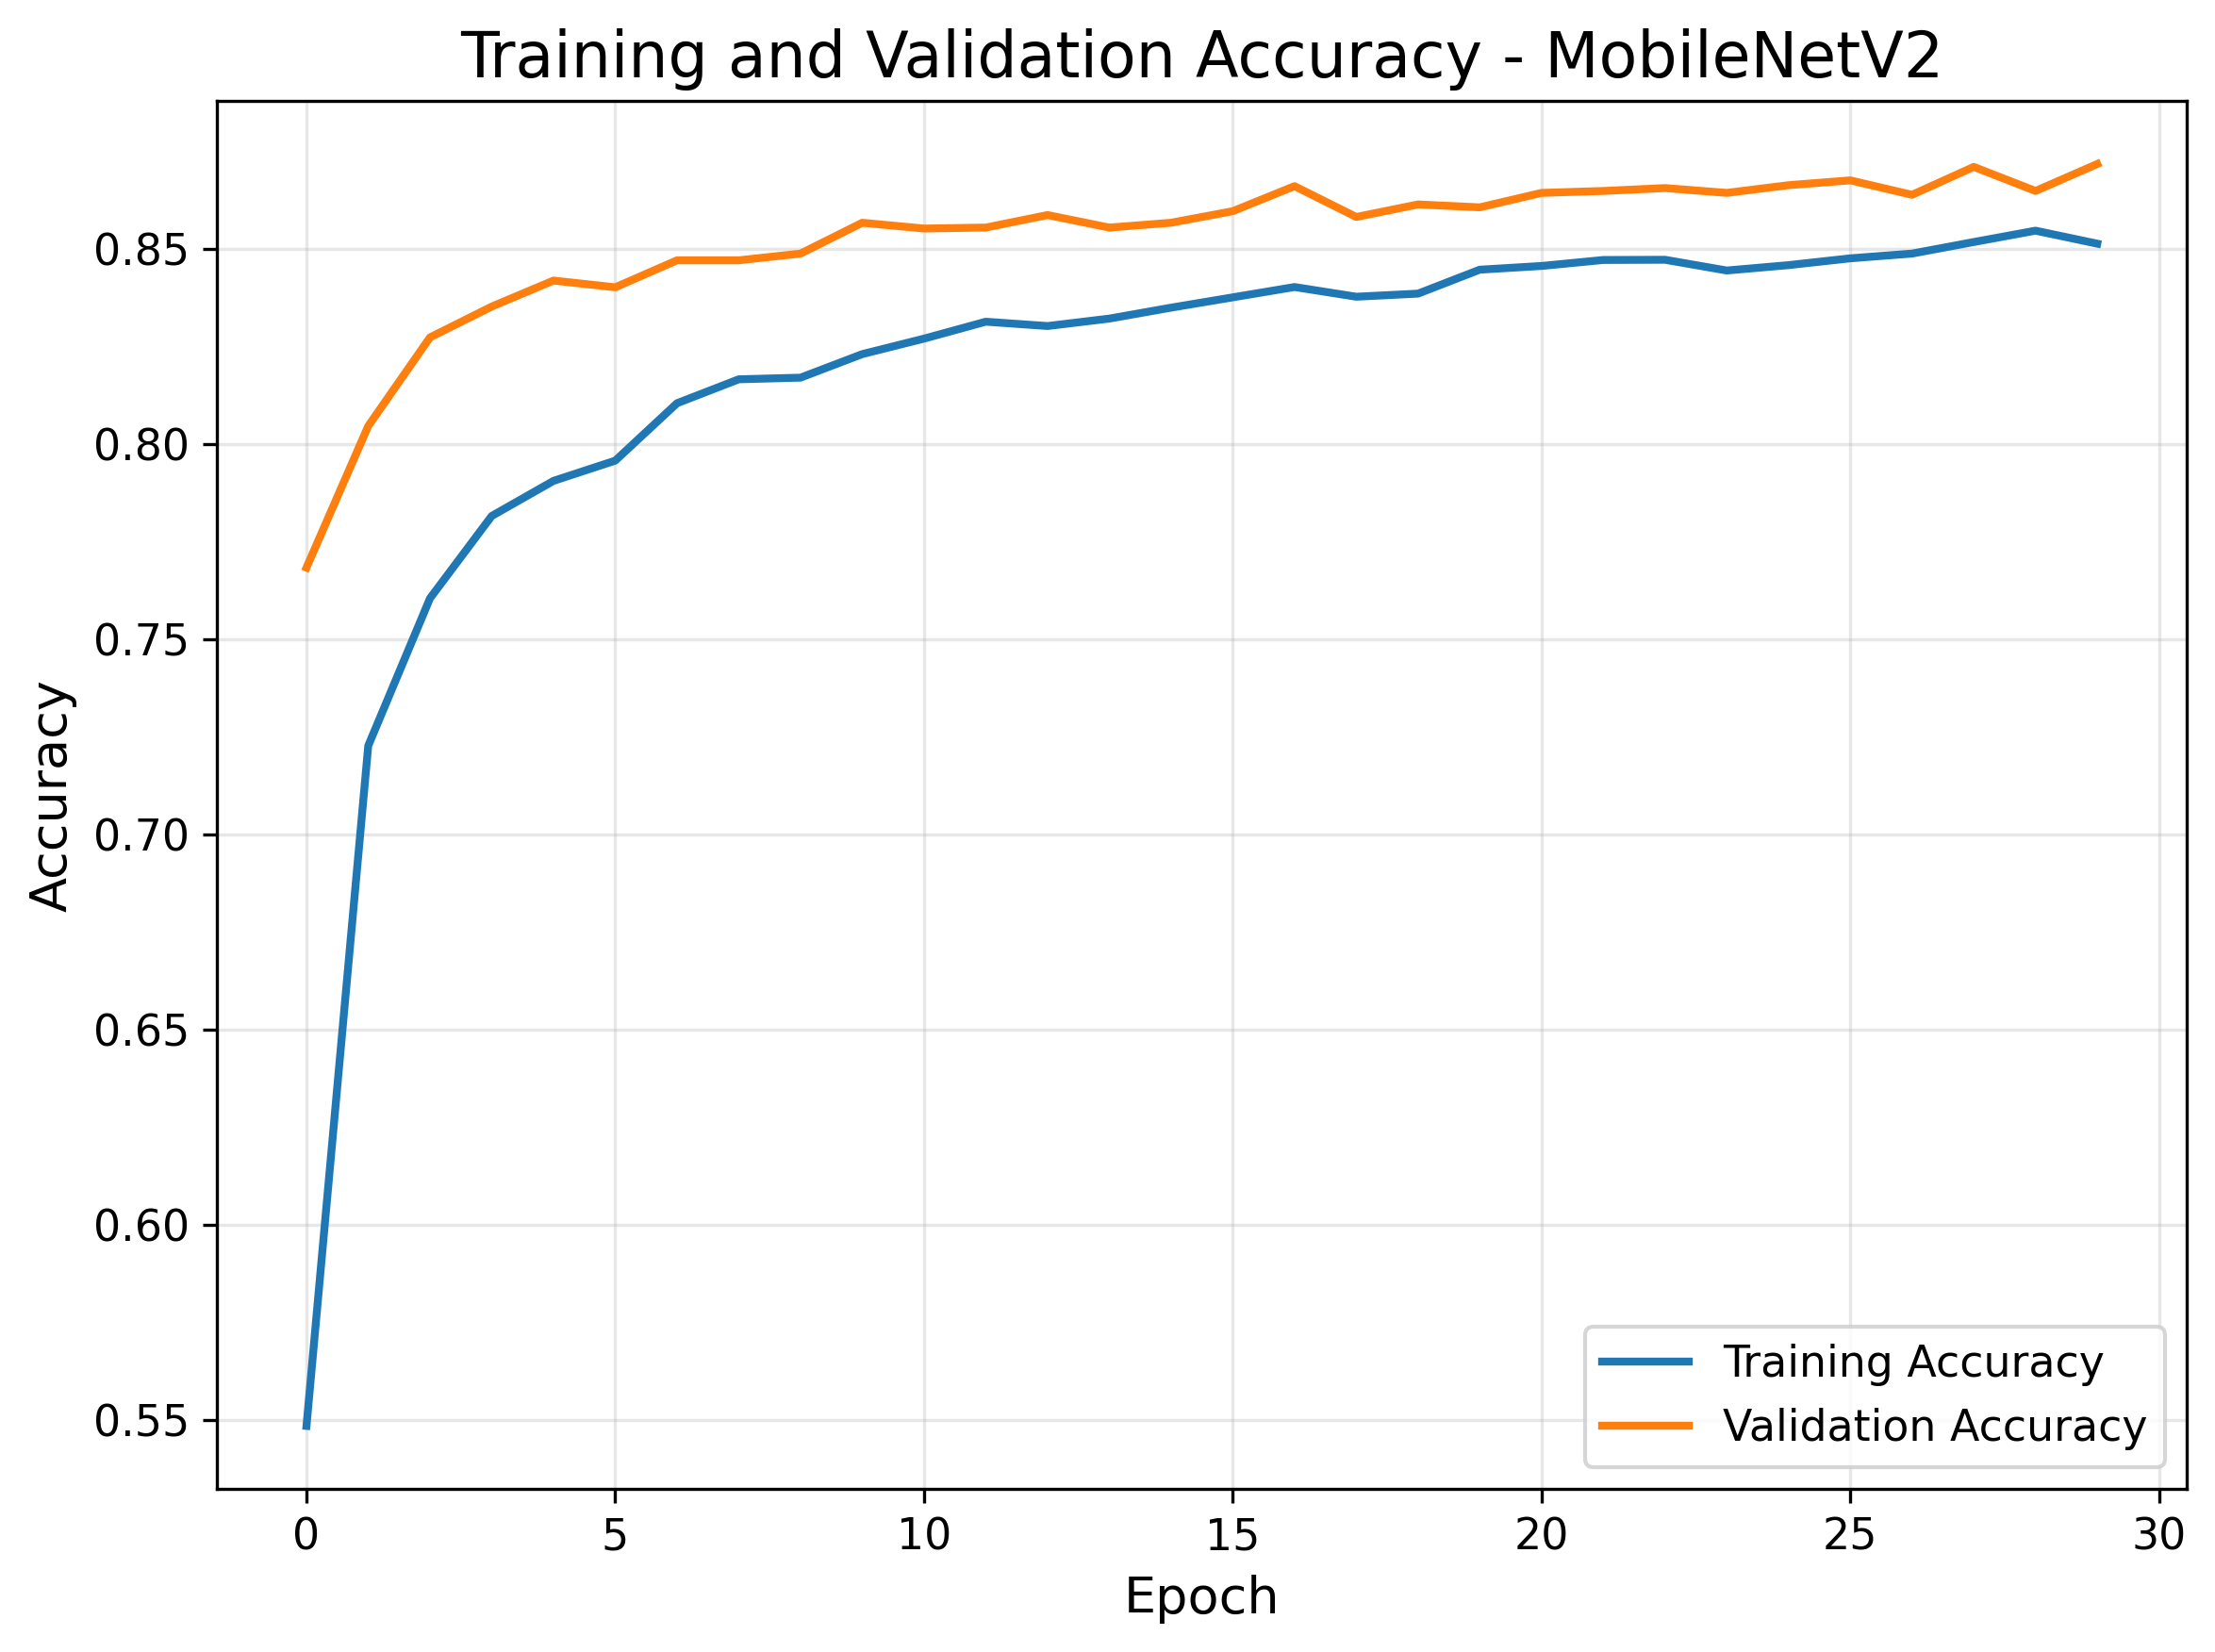

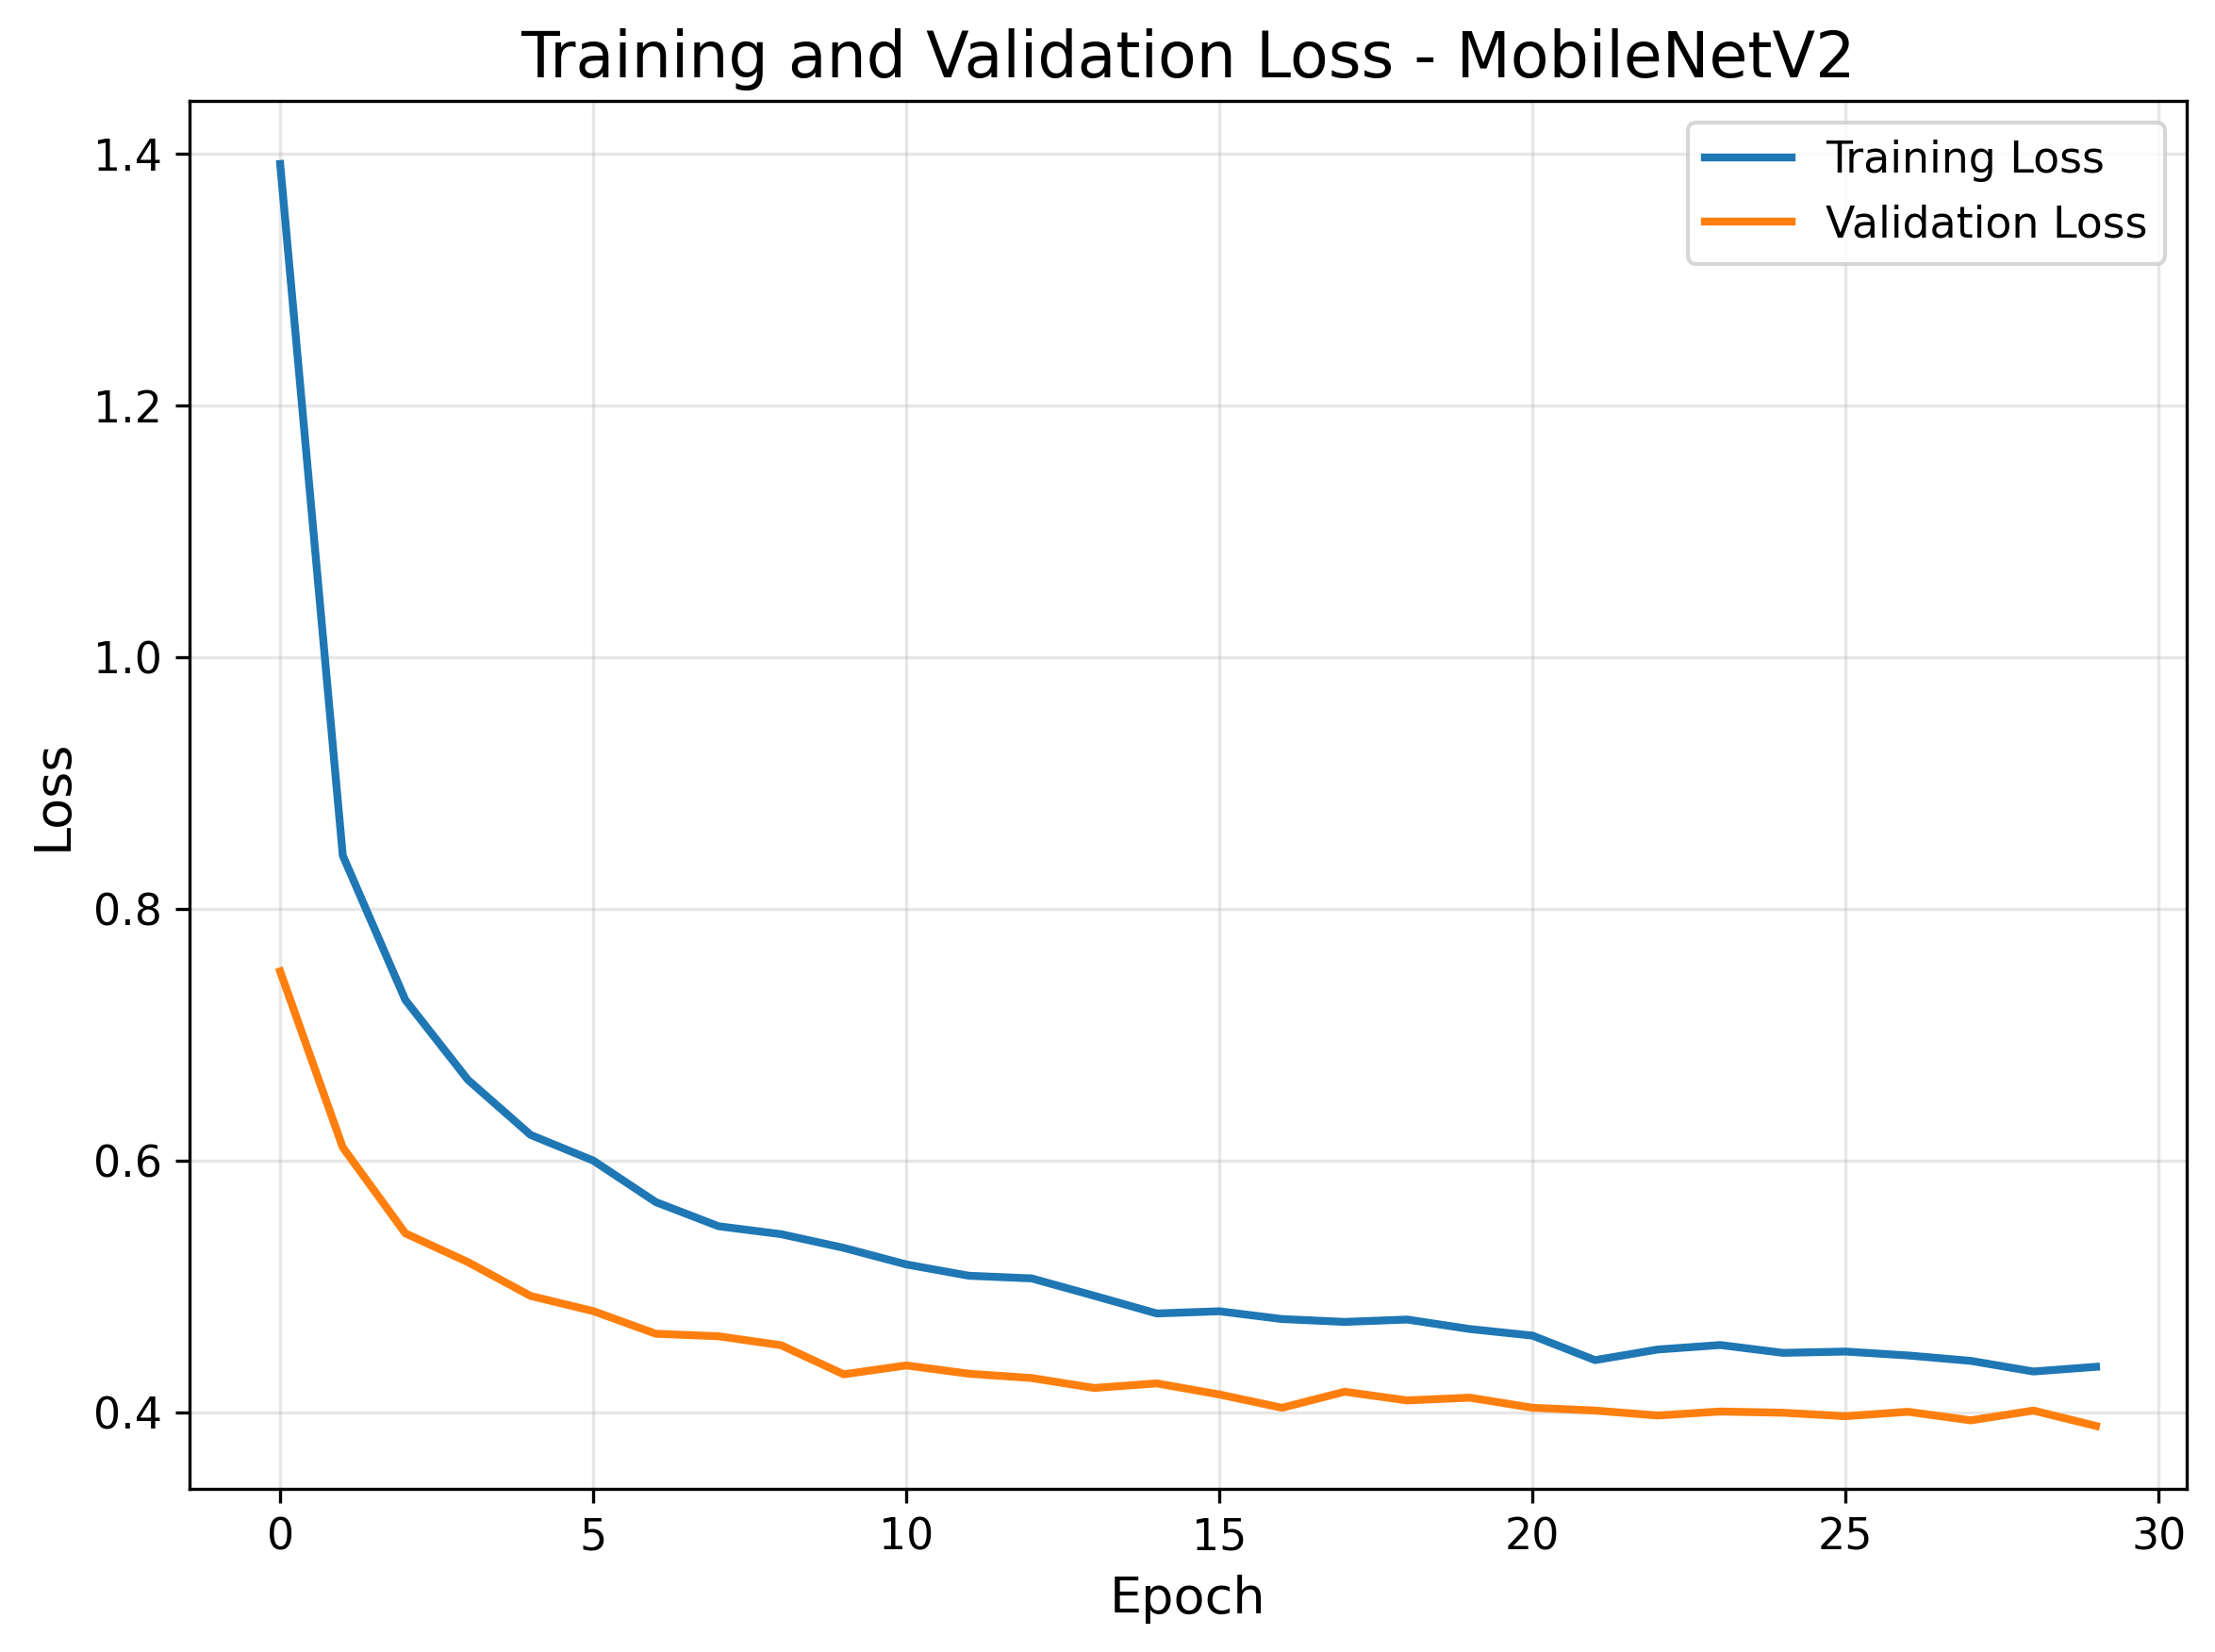

In [45]:
# ============================================================
# Step 8.8 - MobileNetV2 Training Curves
# ============================================================

import matplotlib.pyplot as plt

# -----------------------------
# Accuracy
# -----------------------------

plt.figure(figsize=(8,6))

plt.plot(
    history_mobilenet.history["accuracy"],
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history_mobilenet.history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy - MobileNetV2")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "outputs/figures/mobilenet_accuracy.pdf",
    bbox_inches="tight"
)

plt.show()

# -----------------------------
# Loss
# -----------------------------

plt.figure(figsize=(8,6))

plt.plot(
    history_mobilenet.history["loss"],
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history_mobilenet.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.title("Training and Validation Loss - MobileNetV2")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "outputs/figures/mobilenet_loss.pdf",
    bbox_inches="tight"
)

plt.show()

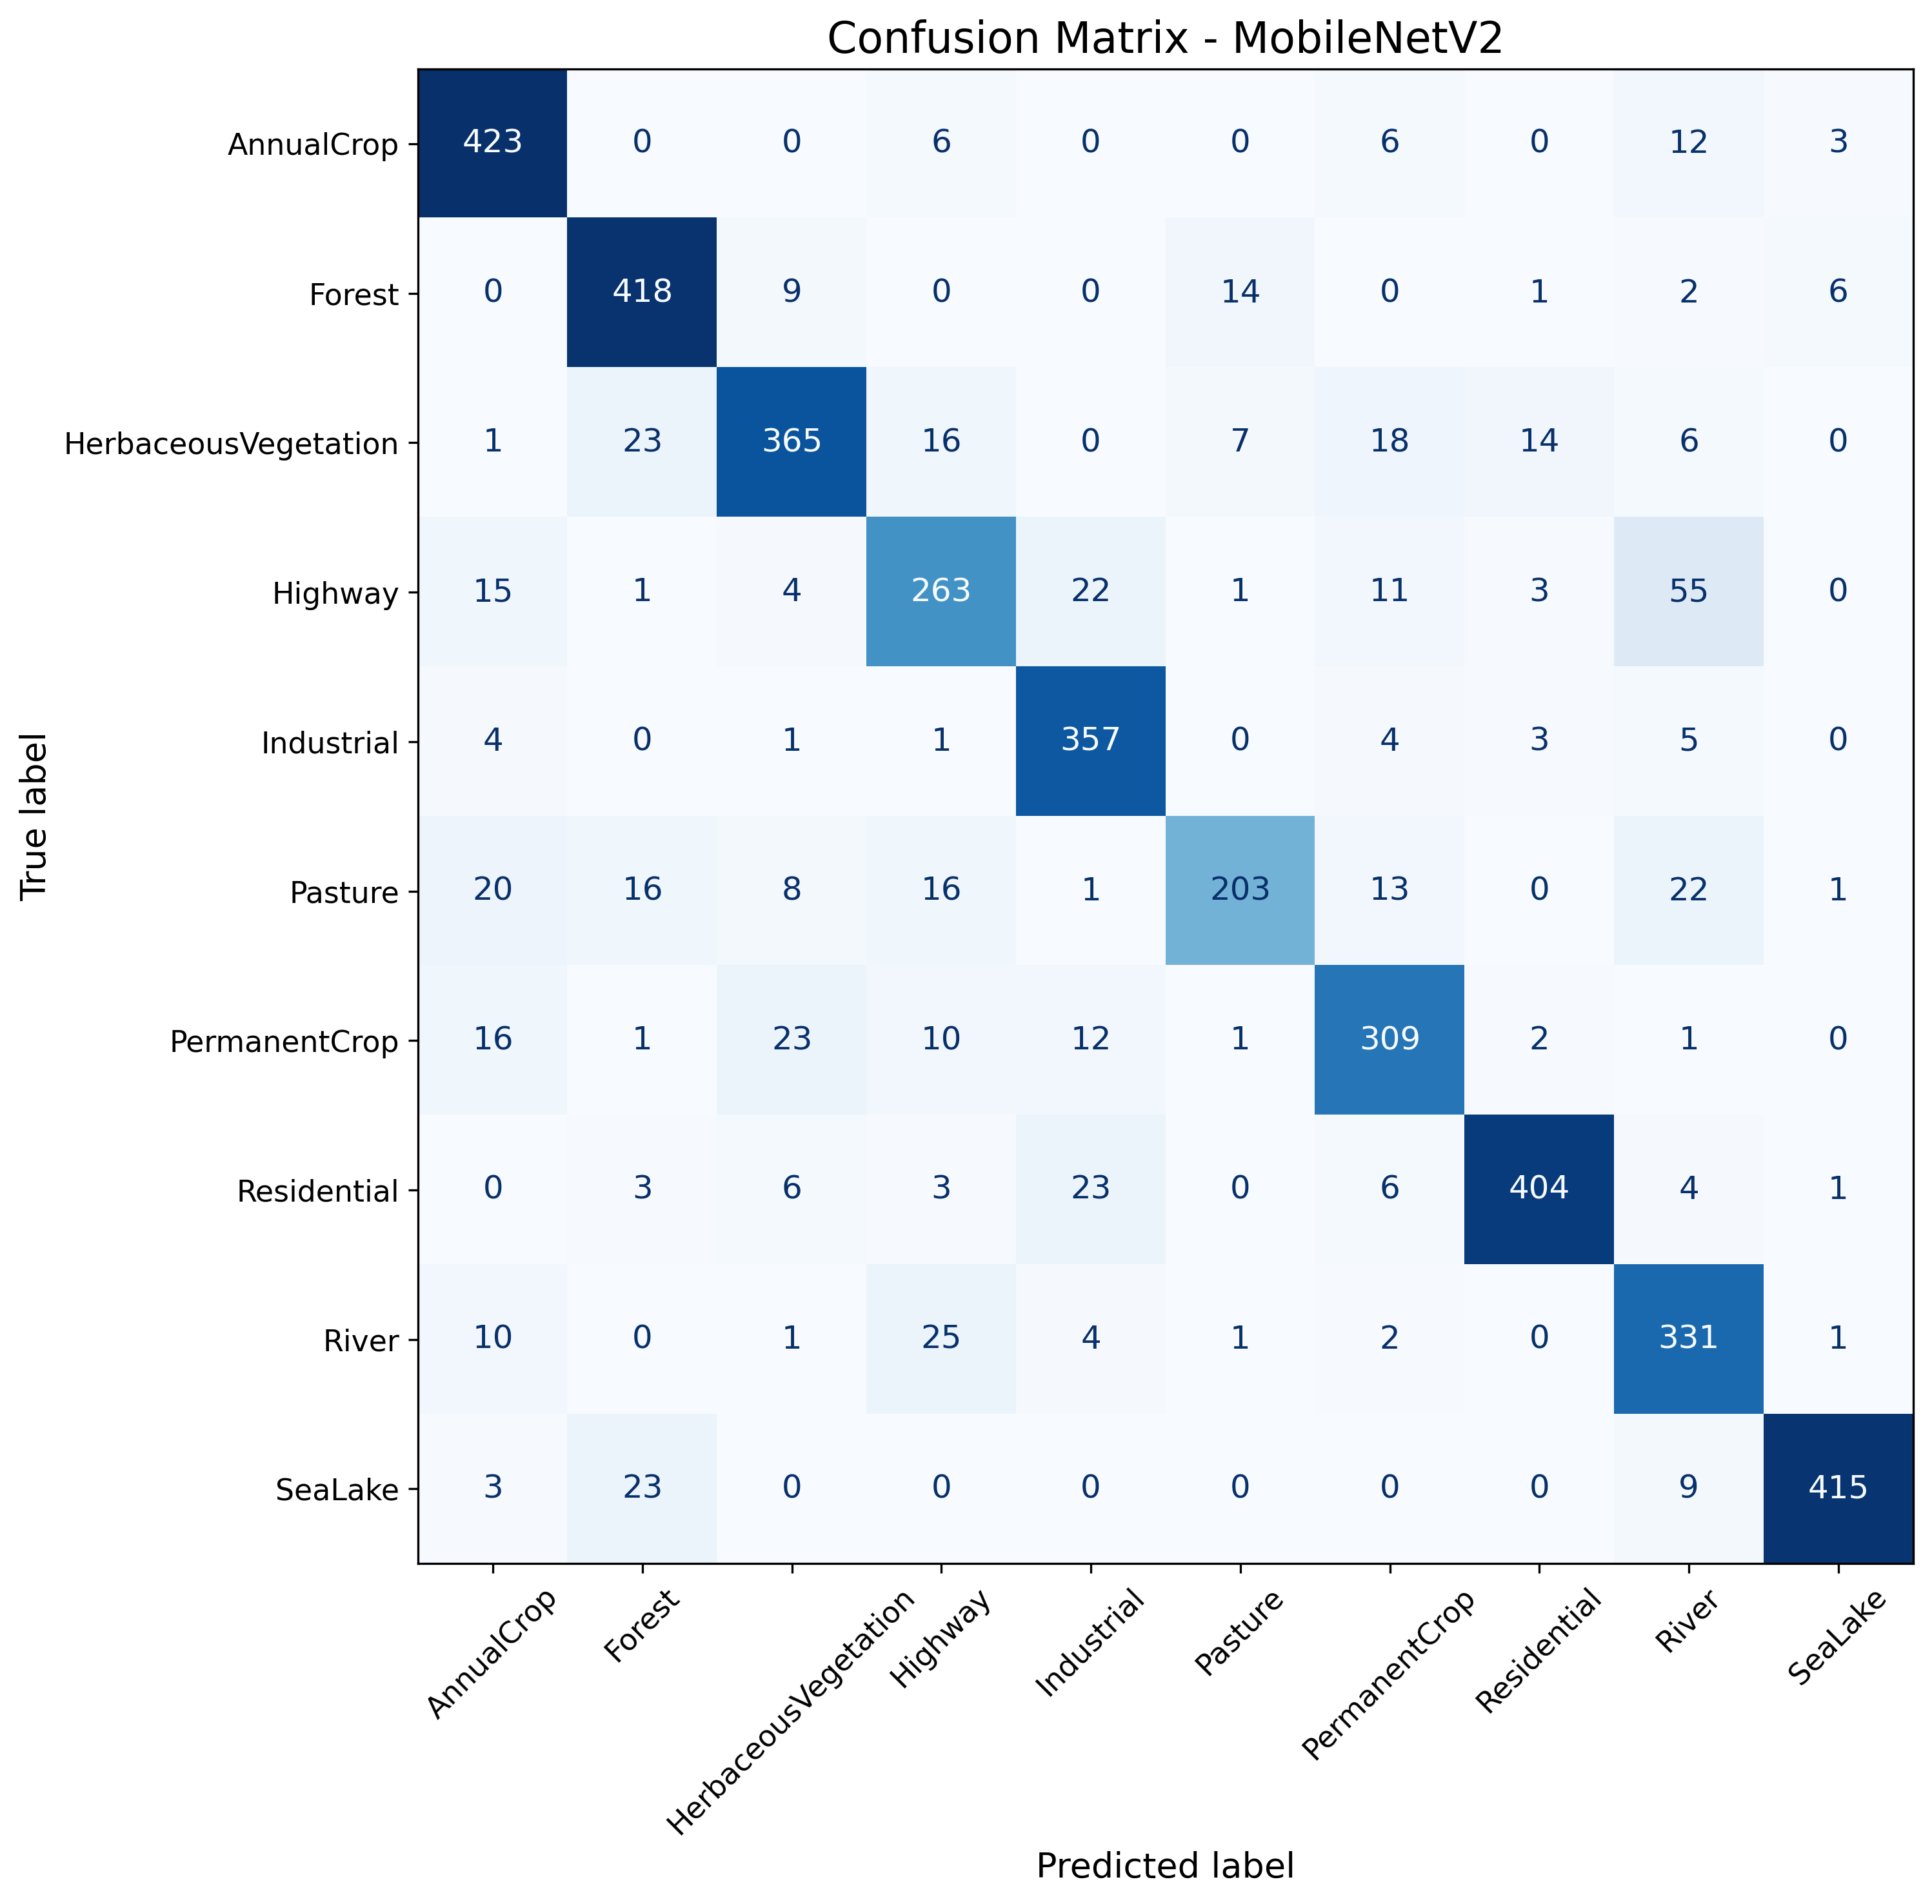

In [46]:
# ============================================================
# Step 8.9 - MobileNetV2 Confusion Matrix
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = mobilenet_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(figsize=(11,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title(
    "Confusion Matrix - MobileNetV2",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "outputs/confusion_matrices/mobilenet_confusion_matrix.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# ============================================================
# Step 8.10 - MobileNetV2 Classification Report
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df = report_df.round(4)

display(report_df)

report_df.to_csv(
    "outputs/tables/mobilenet_classification_report.csv"
)

print("Classification report saved.")

,precision,recall,f1-score,support
AnnualCrop,0.8598,0.9400,0.8981,450.0000
Forest,0.8619,0.9289,0.8941,450.0000
HerbaceousVegetation,0.8753,0.8111,0.8420,450.0000
Highway,0.7735,0.7013,0.7357,375.0000
Industrial,0.8520,0.9520,0.8992,375.0000
Pasture,0.8943,0.6767,0.7704,300.0000
PermanentCrop,0.8374,0.8240,0.8306,375.0000
Residential,0.9461,0.8978,0.9213,450.0000
River,0.7405,0.8827,0.8054,375.0000
SeaLake,0.9719,0.9222,0.9464,450.0000


Classification report saved.


In [48]:
# ============================================================
# Step 8.11 - Update Comparison Table
# ============================================================

comparison_results = pd.DataFrame({

    "Model":[
        "Custom CNN",
        "MobileNetV2"
    ],

    "Training Accuracy (%)":[
        history.history["accuracy"][-1]*100,
        history_mobilenet_finetune.history["accuracy"][-1]*100
    ],

    "Validation Accuracy (%)":[
        history.history["val_accuracy"][-1]*100,
        max(history_mobilenet_finetune.history["val_accuracy"])*100
    ],

    "Test Accuracy (%)":[
        test_accuracy*100,
        test_accuracy_mobilenet*100
    ],

    "Test Loss":[
        test_loss,
        test_loss_mobilenet
    ],

    "Parameters":[
        custom_cnn_model.count_params(),
        mobilenet_model.count_params()
    ]

})

comparison_results = comparison_results.round(2)

display(comparison_results)

comparison_results.to_csv(
    "outputs/tables/model_comparison.csv",
    index=False
)

,Model,Training Accuracy (%),Validation Accuracy (%),Test Accuracy (%),Test Loss,Parameters
0,Custom CNN,92.44,89.63,89.70,0.35,2194122
1,MobileNetV2,85.22,86.94,86.12,0.44,2588490


In [49]:
print("MobileNet Test Accuracy :", test_accuracy_mobilenet)
print("MobileNet Test Loss     :", test_loss_mobilenet)

MobileNet Test Accuracy : 0.8612345457077026
MobileNet Test Loss     : 0.4392675757408142


# 9. EfficientNetB0 Transfer Learning

EfficientNetB0 is selected as the second transfer learning model due to its compound scaling strategy, which balances network depth, width, and image resolution. Fine-tuning the pre-trained network enables the extraction of high-level semantic features, resulting in improved classification performance on the EuroSAT dataset.

In [50]:
# ============================================================
# Step 9.1 - Build EfficientNetB0
# ============================================================

import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import (
    Input,
    Rescaling,
    Lambda,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

# --------------------------------------------------
# Load EfficientNetB0
# --------------------------------------------------

base_model_eff = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_shape=(64,64,3)

)

# Freeze backbone
base_model_eff.trainable = False

# --------------------------------------------------
# Build Network
# --------------------------------------------------

inputs = Input(shape=(64,64,3))

x = data_augmentation(inputs)

# Convert [0,1] → [0,255]
x = Rescaling(255.0)(x)

# EfficientNet preprocessing
x = Lambda(preprocess_input)(x)

# Backbone
x = base_model_eff(x, training=False)

# Classification Head
x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

efficientnet_model = Model(

    inputs,

    outputs,

    name="EfficientNetB0"

)

print("EfficientNetB0 created successfully.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 created successfully.


In [51]:
# ============================================================
# Step 9.2 - Model Summary
# ============================================================

efficientnet_model.summary()

Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Data_Augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [52]:
# ============================================================
# Step 9.3 - Compile EfficientNetB0
# ============================================================

from tensorflow.keras.optimizers import Adam

efficientnet_model.compile(

    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("EfficientNetB0 compiled successfully.")

EfficientNetB0 compiled successfully.


In [53]:
# ============================================================
# Step 9.4 - EfficientNetB0 Callbacks
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

efficientnet_early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1

)

efficientnet_checkpoint = ModelCheckpoint(

    filepath="models/efficientnetb0_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

efficientnet_reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

efficientnet_callbacks = [

    efficientnet_early_stopping,

    efficientnet_checkpoint,

    efficientnet_reduce_lr

]

print("Callbacks configured successfully.")

Callbacks configured successfully.


In [54]:
# ============================================================
# Step 9.5 - Train EfficientNetB0
# ============================================================

import time

start_time = time.time()

history_efficientnet = efficientnet_model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=EPOCHS,

    callbacks=efficientnet_callbacks,

    verbose=1

)

training_time_efficientnet = time.time() - start_time

print("\nTraining completed successfully.")

print(f"Training Time : {training_time_efficientnet:.2f} seconds")

Epoch 1/30


E0000 00:00:1782634633.798533      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


588/591 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5357 - loss: 1.4392
Epoch 1: val_accuracy improved from None to 0.86691, saving model to models/efficientnetb0_best.keras

Epoch 1: finished saving model to models/efficientnetb0_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.6744 - loss: 1.0291 - val_accuracy: 0.8669 - val_loss: 0.4647 - learning_rate: 1.0000e-04
Epoch 2/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8010 - loss: 0.6107
Epoch 2: val_accuracy improved from 0.86691 to 0.88864, saving model to models/efficientnetb0_best.keras

Epoch 2: finished saving model to models/efficientnetb0_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8099 - loss: 0.5783 - val_accuracy: 0.8886 - val_loss: 0.3634 - learning_rate: 1.0000e-04
Epoch 3/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8317 - loss: 0.5121
Epoch 3: val_accuracy improved from 0.88864 to 0.89605, saving model to models/efficientnetb0_best.keras

Epoch 3

In [55]:
history_df = pd.DataFrame(history_efficientnet.history)

history_df.to_csv(
    "outputs/tables/efficientnet_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [56]:
# ============================================================
# Step 9.6 - EfficientNetB0 Test Evaluation
# ============================================================

test_loss_efficientnet, test_accuracy_efficientnet = efficientnet_model.evaluate(
    test_dataset,
    verbose=1
)

print("=" * 60)
print("EFFICIENTNETB0 TEST PERFORMANCE")
print("=" * 60)

print(f"Test Accuracy : {test_accuracy_efficientnet:.4f}")
print(f"Test Loss     : {test_loss_efficientnet:.4f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9205 - loss: 0.2269
EFFICIENTNETB0 TEST PERFORMANCE
Test Accuracy : 0.9205
Test Loss     : 0.2269


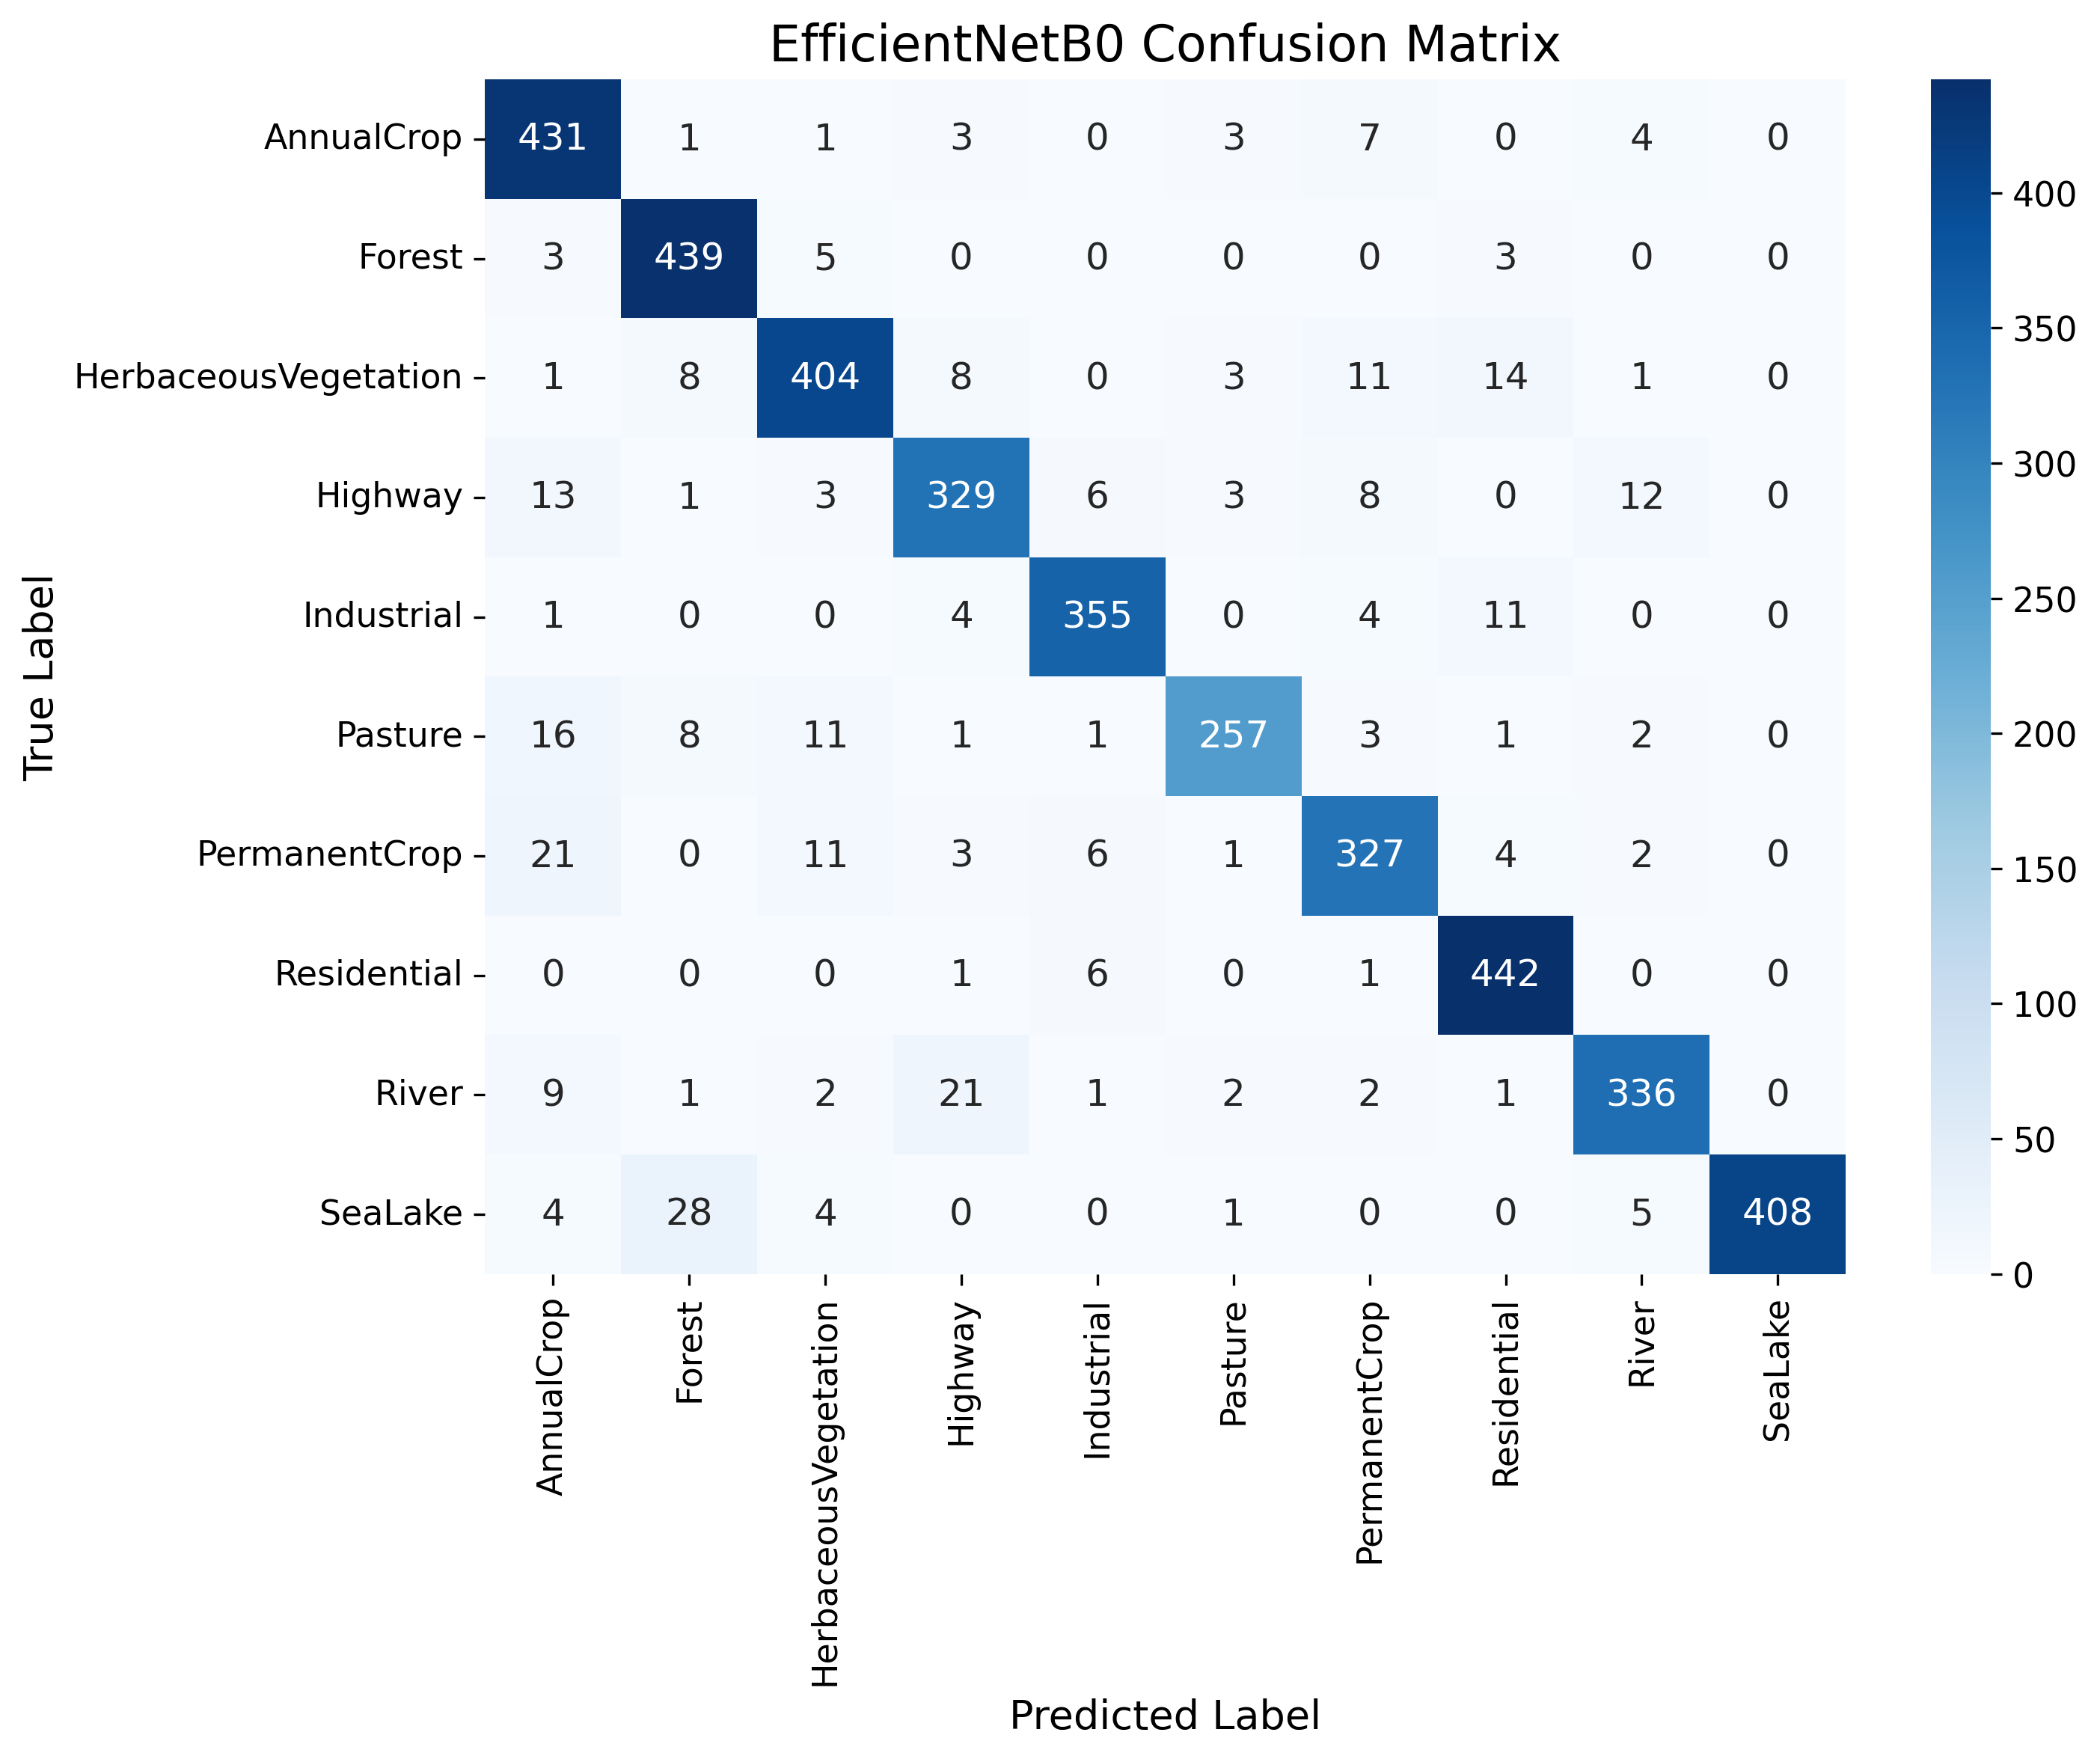

EfficientNetB0 confusion matrix saved successfully.


In [57]:
# ============================================================
# Step 9.7 - EfficientNetB0 Confusion Matrix
# ============================================================

import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

# Create output folder
os.makedirs("outputs/confusion_matrices", exist_ok=True)

# Collect predictions
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = efficientnet_model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("EfficientNetB0 Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "outputs/confusion_matrices/efficientnet_confusion_matrix.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("EfficientNetB0 confusion matrix saved successfully.")

In [58]:
# ============================================================
# Step 9.8 - EfficientNet Classification Report
# ============================================================

import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_csv(
    "outputs/tables/efficientnet_classification_report.csv"
)

print("EfficientNet classification report saved successfully.")

,precision,recall,f1-score,support
AnnualCrop,0.863727,0.957778,0.908325,450.000000
Forest,0.903292,0.975556,0.938034,450.000000
HerbaceousVegetation,0.916100,0.897778,0.906846,450.000000
Highway,0.889189,0.877333,0.883221,375.000000
Industrial,0.946667,0.946667,0.946667,375.000000
Pasture,0.951852,0.856667,0.901754,300.000000
PermanentCrop,0.900826,0.872000,0.886179,375.000000
Residential,0.928571,0.982222,0.954644,450.000000
River,0.928177,0.896000,0.911805,375.000000
SeaLake,1.000000,0.906667,0.951049,450.000000


EfficientNet classification report saved successfully.


In [59]:
# ============================================================
# Step 9.9 - Final Model Comparison
# ============================================================

import pandas as pd

comparison_results = pd.DataFrame({

    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "EfficientNetB0"
    ],

    "Training Accuracy (%)": [
        history.history["accuracy"][-1] * 100,
        history_mobilenet_finetune.history["accuracy"][-1] * 100,
        history_efficientnet.history["accuracy"][-1] * 100
    ],

    "Validation Accuracy (%)": [
        history.history["val_accuracy"][-1] * 100,
        max(history_mobilenet_finetune.history["val_accuracy"]) * 100,
        max(history_efficientnet.history["val_accuracy"]) * 100
    ],

    "Test Accuracy (%)": [
        test_accuracy * 100,
        test_accuracy_mobilenet * 100,
        test_accuracy_efficientnet * 100
    ],

    "Test Loss": [
        test_loss,
        test_loss_mobilenet,
        test_loss_efficientnet
    ],

    "Parameters": [
        custom_cnn_model.count_params(),
        mobilenet_model.count_params(),
        efficientnet_model.count_params()
    ]

})

comparison_results = comparison_results.round(2)

display(comparison_results)

comparison_results.to_csv(
    "outputs/tables/model_comparison.csv",
    index=False
)

print("✅ Final comparison table saved successfully.")

,Model,Training Accuracy (%),Validation Accuracy (%),Test Accuracy (%),Test Loss,Parameters
0,Custom CNN,92.44,89.63,89.70,0.35,2194122
1,MobileNetV2,85.22,86.94,86.12,0.44,2588490
2,EfficientNetB0,90.21,92.25,92.05,0.23,4380077


✅ Final comparison table saved successfully.


# 10. ROC Curve Analysis

To further evaluate the classification performance, Receiver Operating Characteristic (ROC) curves are generated for the best-performing model using a One-vs-Rest (OvR) strategy. The Area Under the Curve (AUC) is calculated for each class to measure the model's discriminative ability across different decision thresholds. Higher AUC values indicate stronger classification performance and greater robustness.

In [60]:
# ============================================================
# Step 10.2 - Import Libraries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    roc_curve,
    auc
)

print("ROC libraries imported successfully.")

ROC libraries imported successfully.


In [61]:
# ============================================================
# Step 10.3 - Collect Predictions
# ============================================================

y_true = []
y_scores = []

for images, labels in test_dataset:

    predictions = efficientnet_model.predict(images, verbose=0)

    y_scores.extend(predictions)

    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)

print("True Labels Shape :", y_true.shape)
print("Prediction Shape :", y_scores.shape)

True Labels Shape : (4050,)
Prediction Shape : (4050, 10)


In [62]:
# ============================================================
# Step 10.4 - One Hot Encoding
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

print(y_true_bin.shape)

(4050, 10)


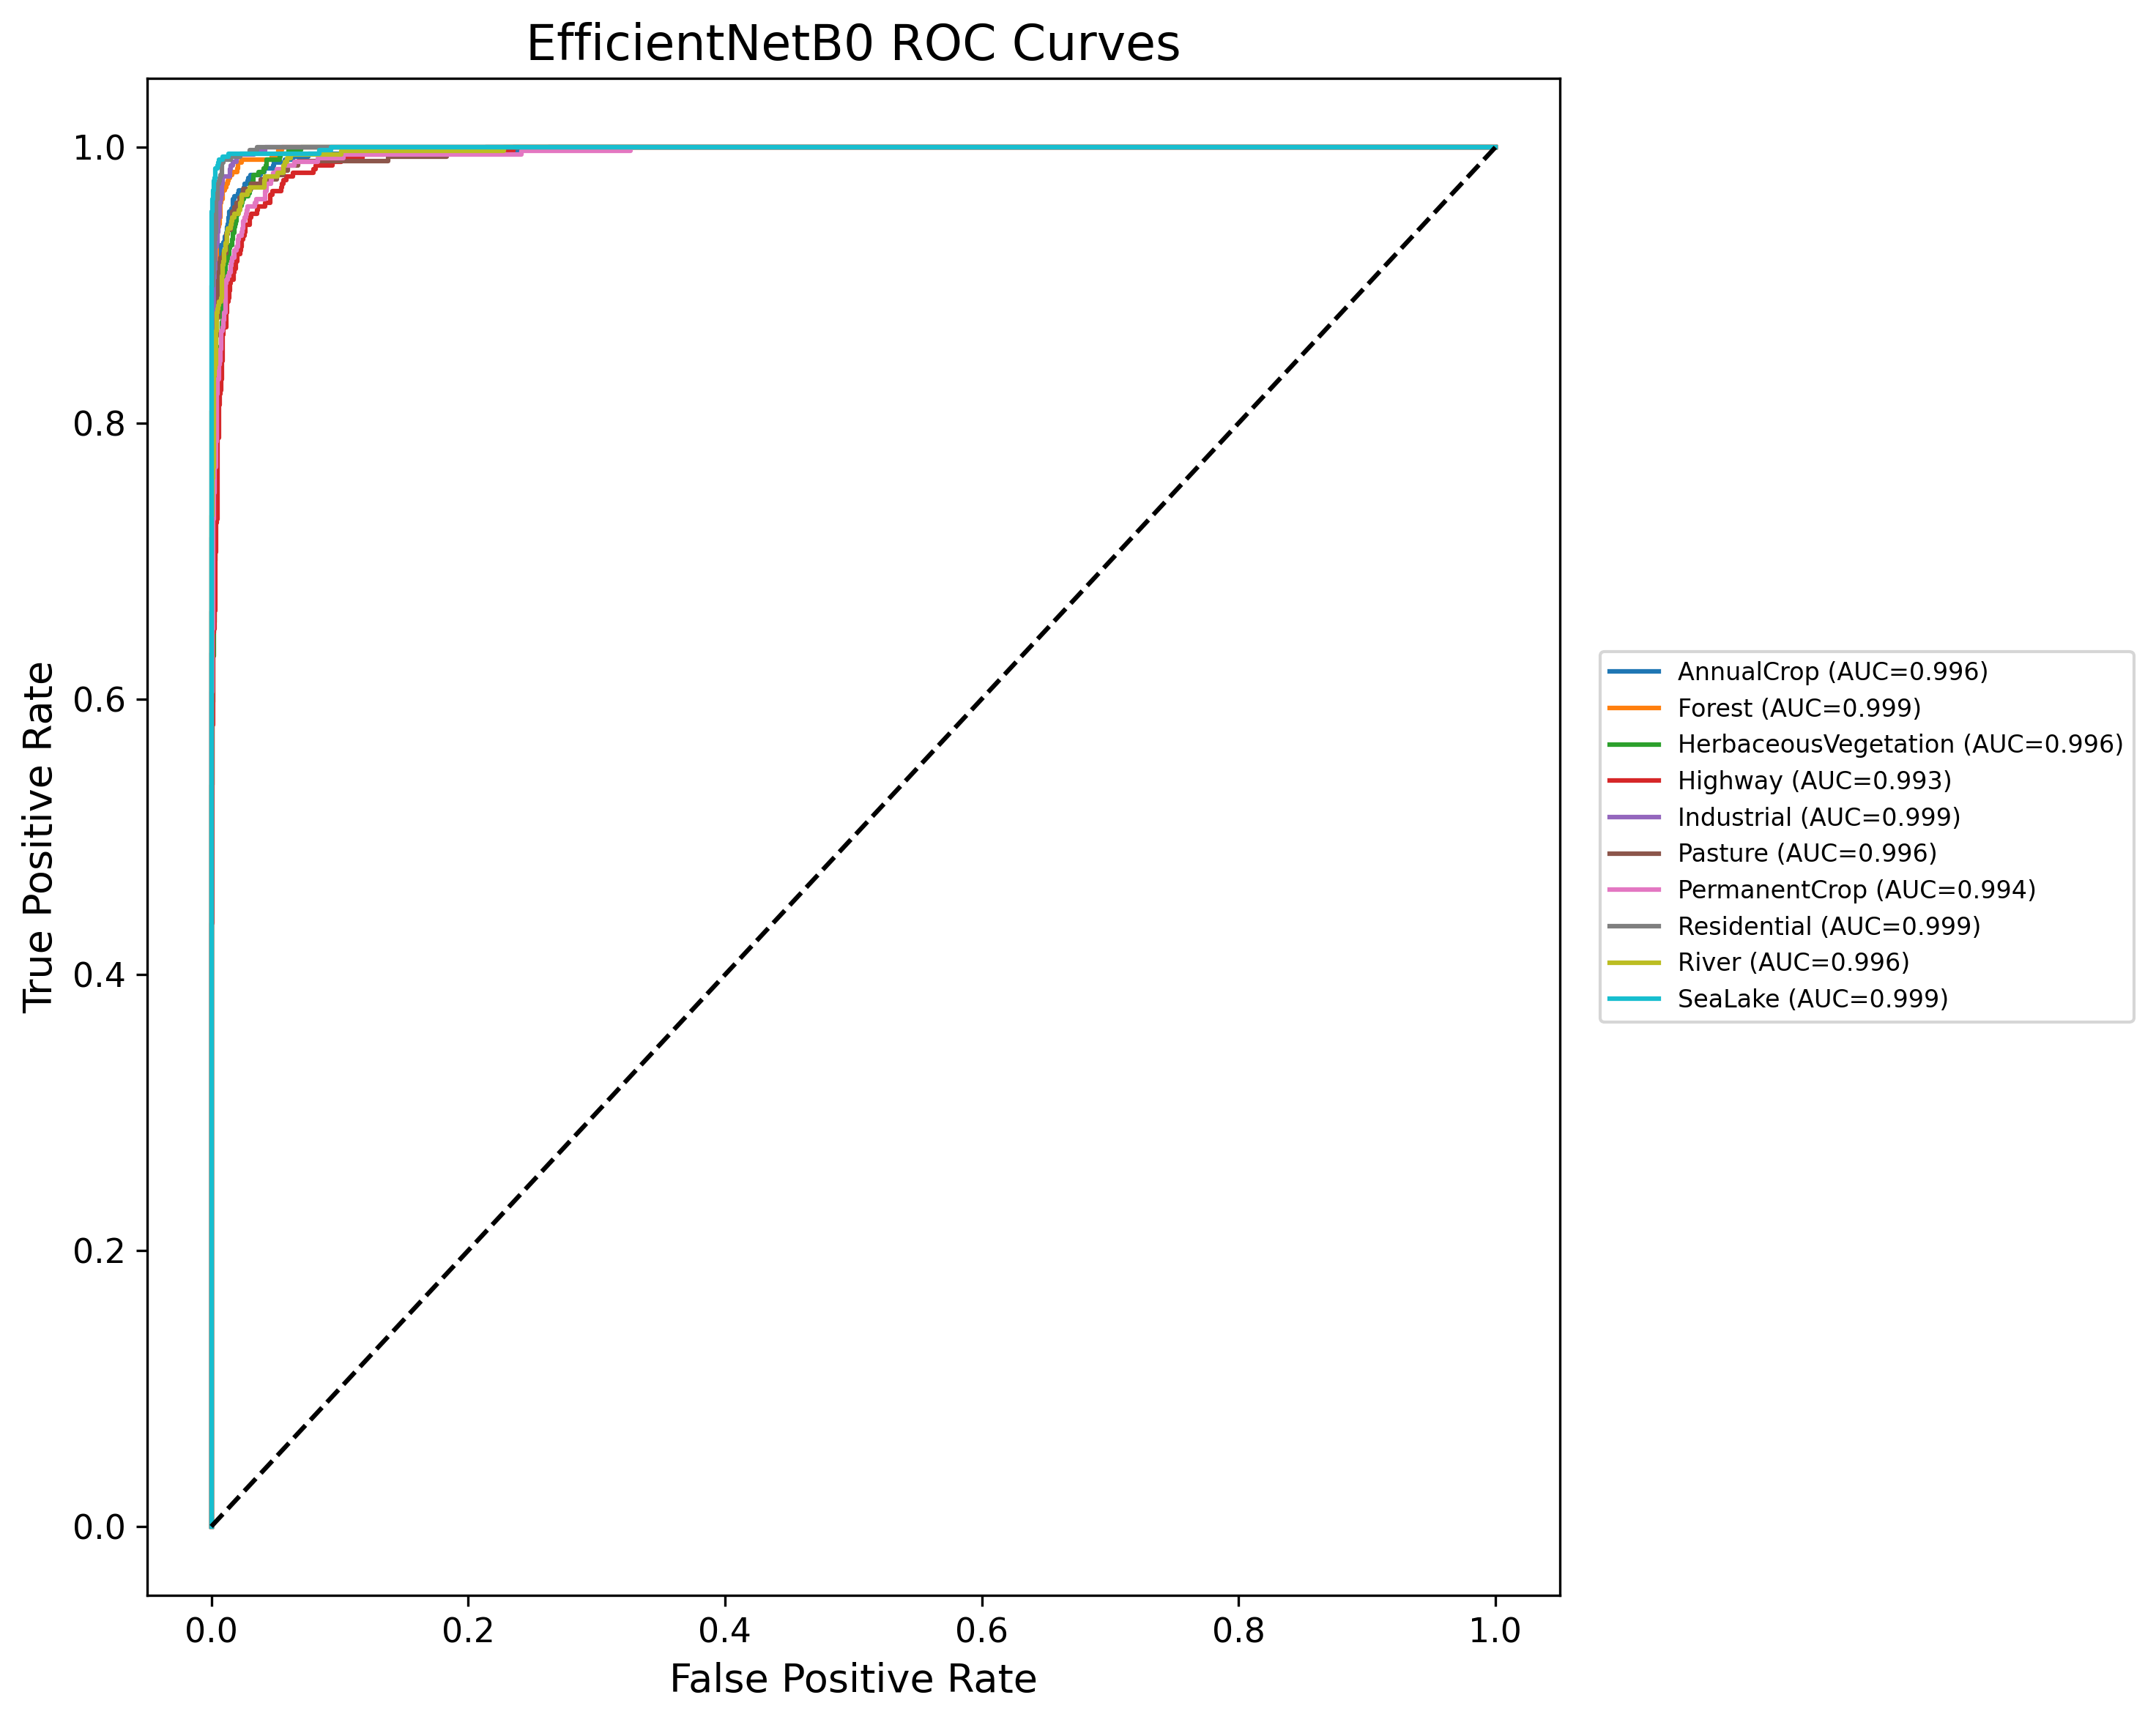

In [63]:
# ============================================================
# Step 10.5 - Plot ROC Curves
# ============================================================

plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_scores[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    "k--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("EfficientNetB0 ROC Curves")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "outputs/roc_curves/efficientnetb0_roc.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 11. Error Analysis

Beyond overall accuracy, a detailed error analysis is performed to investigate the strengths and limitations of the best-performing model. Correctly classified samples, misclassified images, and the most frequently confused class pairs are analyzed to better understand challenging land-cover categories and identify opportunities for future improvement.

In [64]:
# ============================================================
# Step 11.2 - Collect Predictions
# ============================================================

import numpy as np

y_true = []
y_pred = []
all_images = []

for images, labels in test_dataset:

    predictions = efficientnet_model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)
    all_images.extend(images.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
all_images = np.array(all_images)

print("Images :", all_images.shape)
print("True Labels :", y_true.shape)
print("Predicted Labels :", y_pred.shape)

Images : (4050, 64, 64, 3)
True Labels : (4050,)
Predicted Labels : (4050,)


In [65]:
# ============================================================
# Step 11.3 - Prediction Statistics
# ============================================================

correct_idx = np.where(y_true == y_pred)[0]
incorrect_idx = np.where(y_true != y_pred)[0]

print("="*60)
print("Prediction Statistics")
print("="*60)

print(f"Correct Predictions   : {len(correct_idx)}")
print(f"Incorrect Predictions : {len(incorrect_idx)}")

accuracy = len(correct_idx) / len(y_true) * 100

print(f"Accuracy from Predictions : {accuracy:.2f}%")

Prediction Statistics
Correct Predictions   : 3728
Incorrect Predictions : 322
Accuracy from Predictions : 92.05%


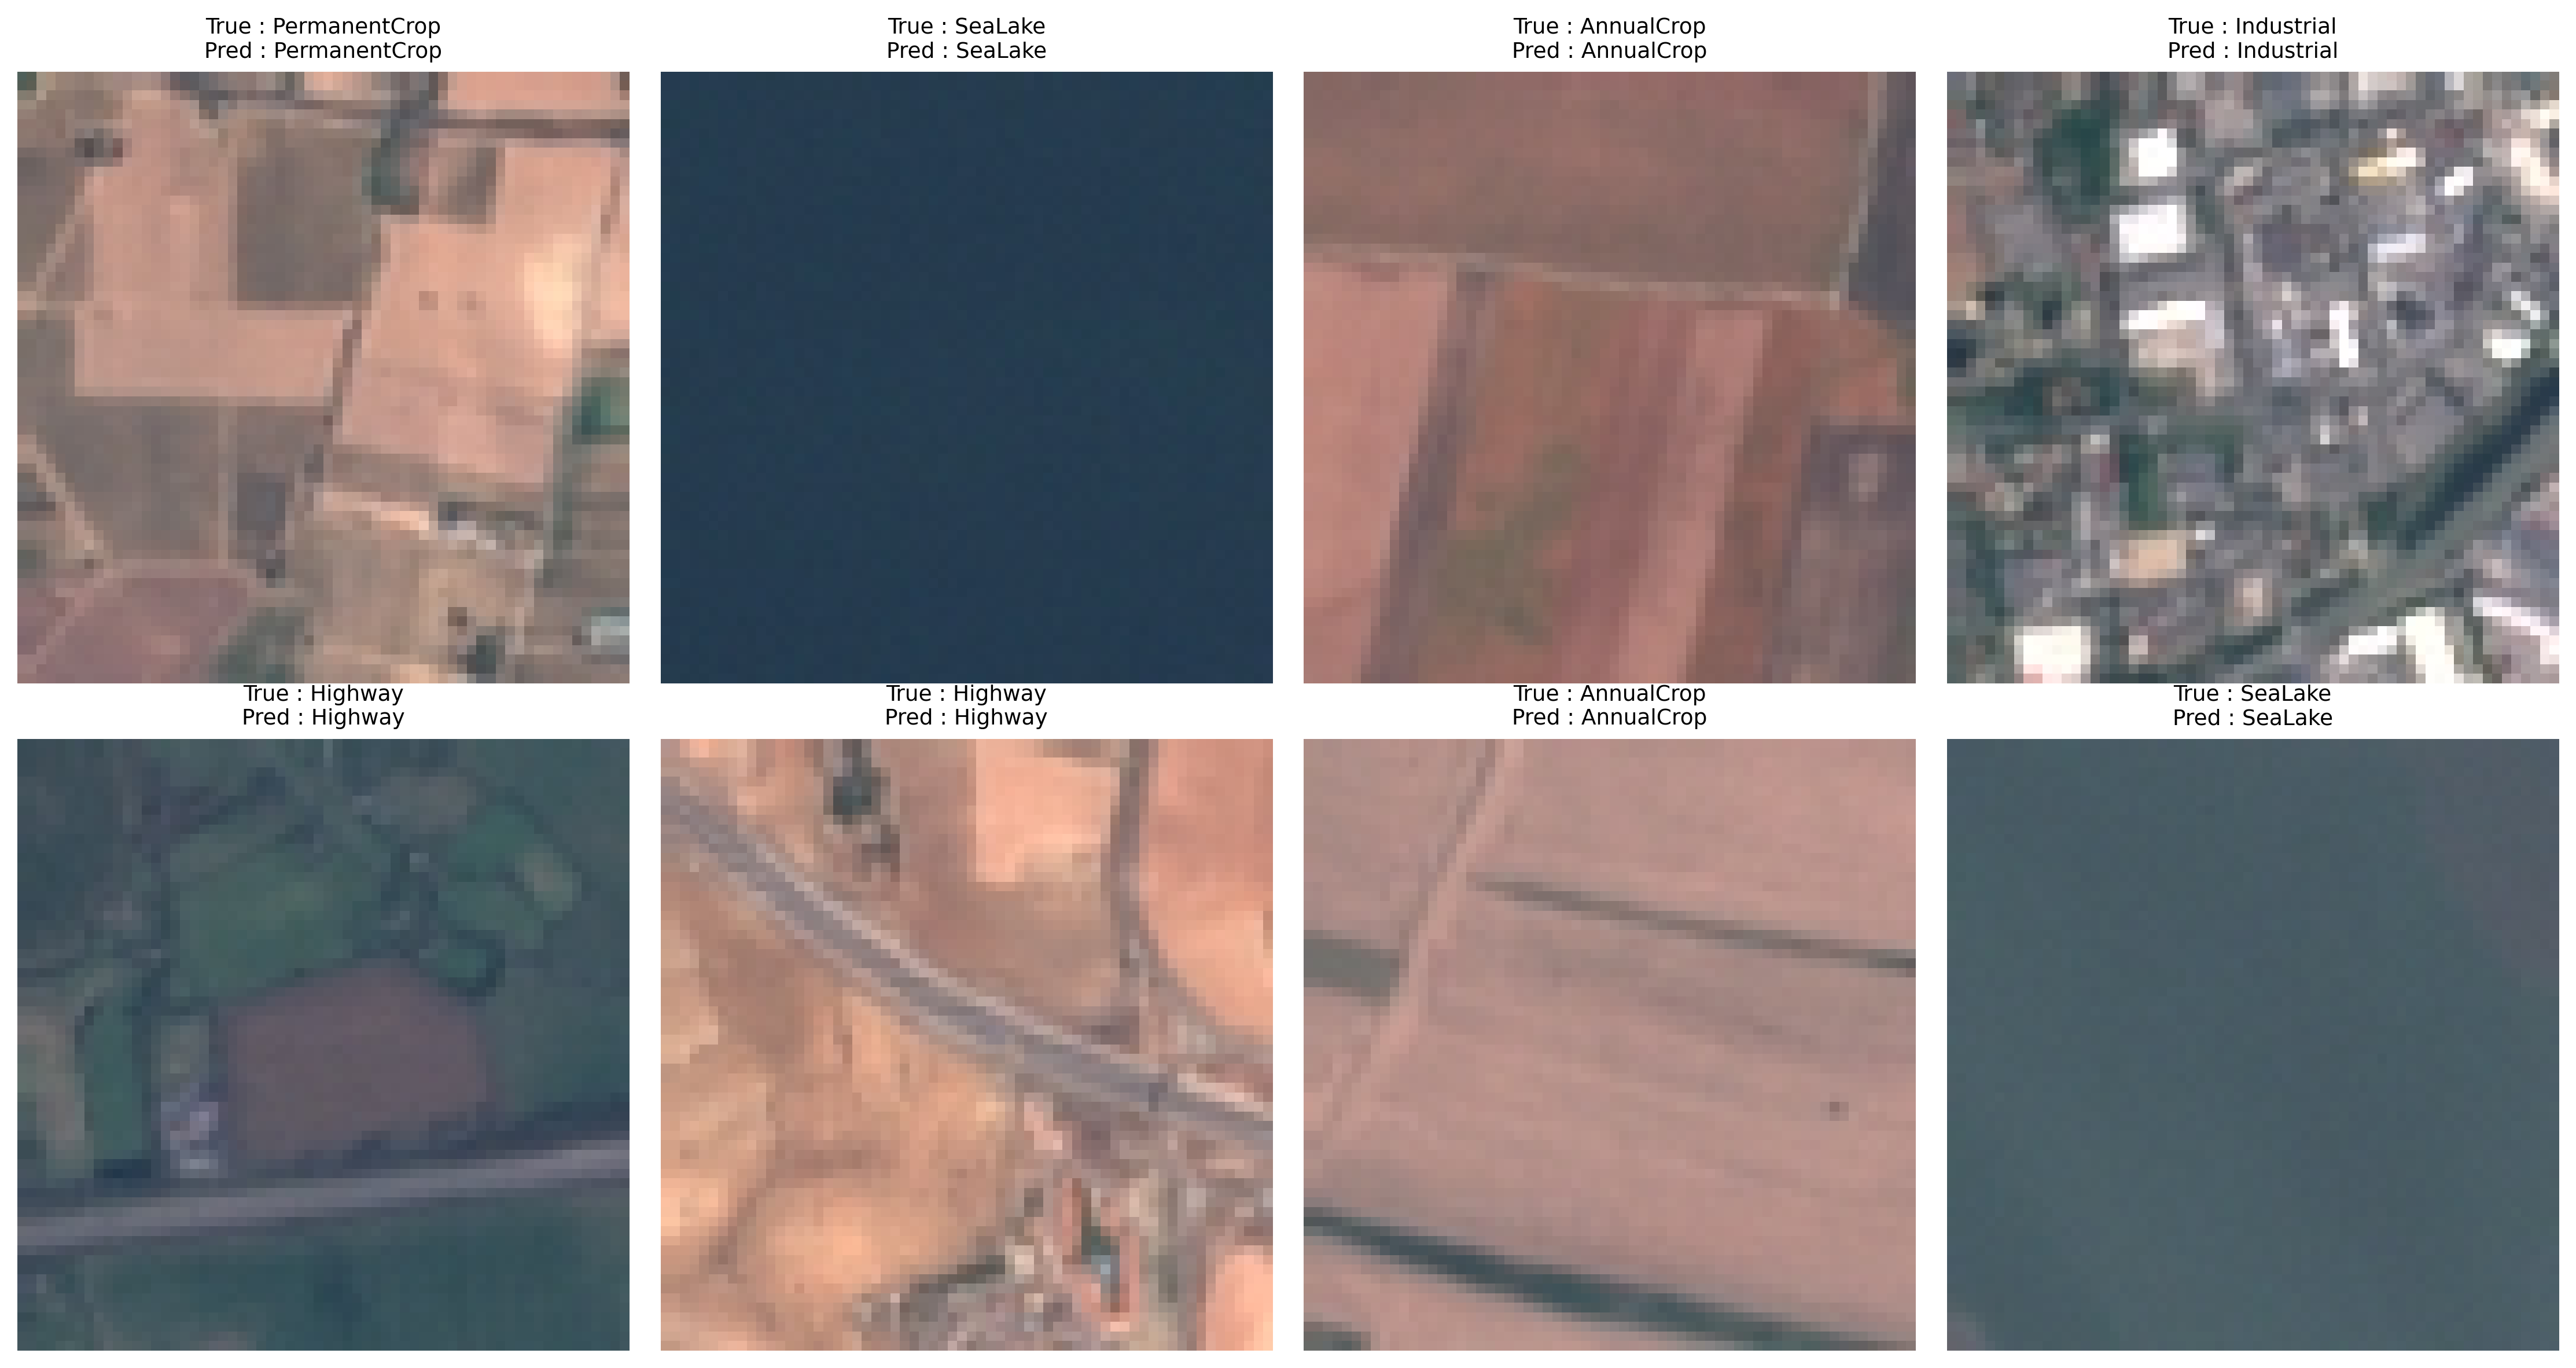

In [66]:
# ============================================================
# Step 11.4 - Correct Predictions
# ============================================================

plt.figure(figsize=(15,8))

for i, idx in enumerate(correct_idx[:8]):

    plt.subplot(2,4,i+1)

    plt.imshow(all_images[idx])

    plt.title(
        f"True : {class_names[y_true[idx]]}\n"
        f"Pred : {class_names[y_pred[idx]]}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "outputs/predictions/correct_predictions.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

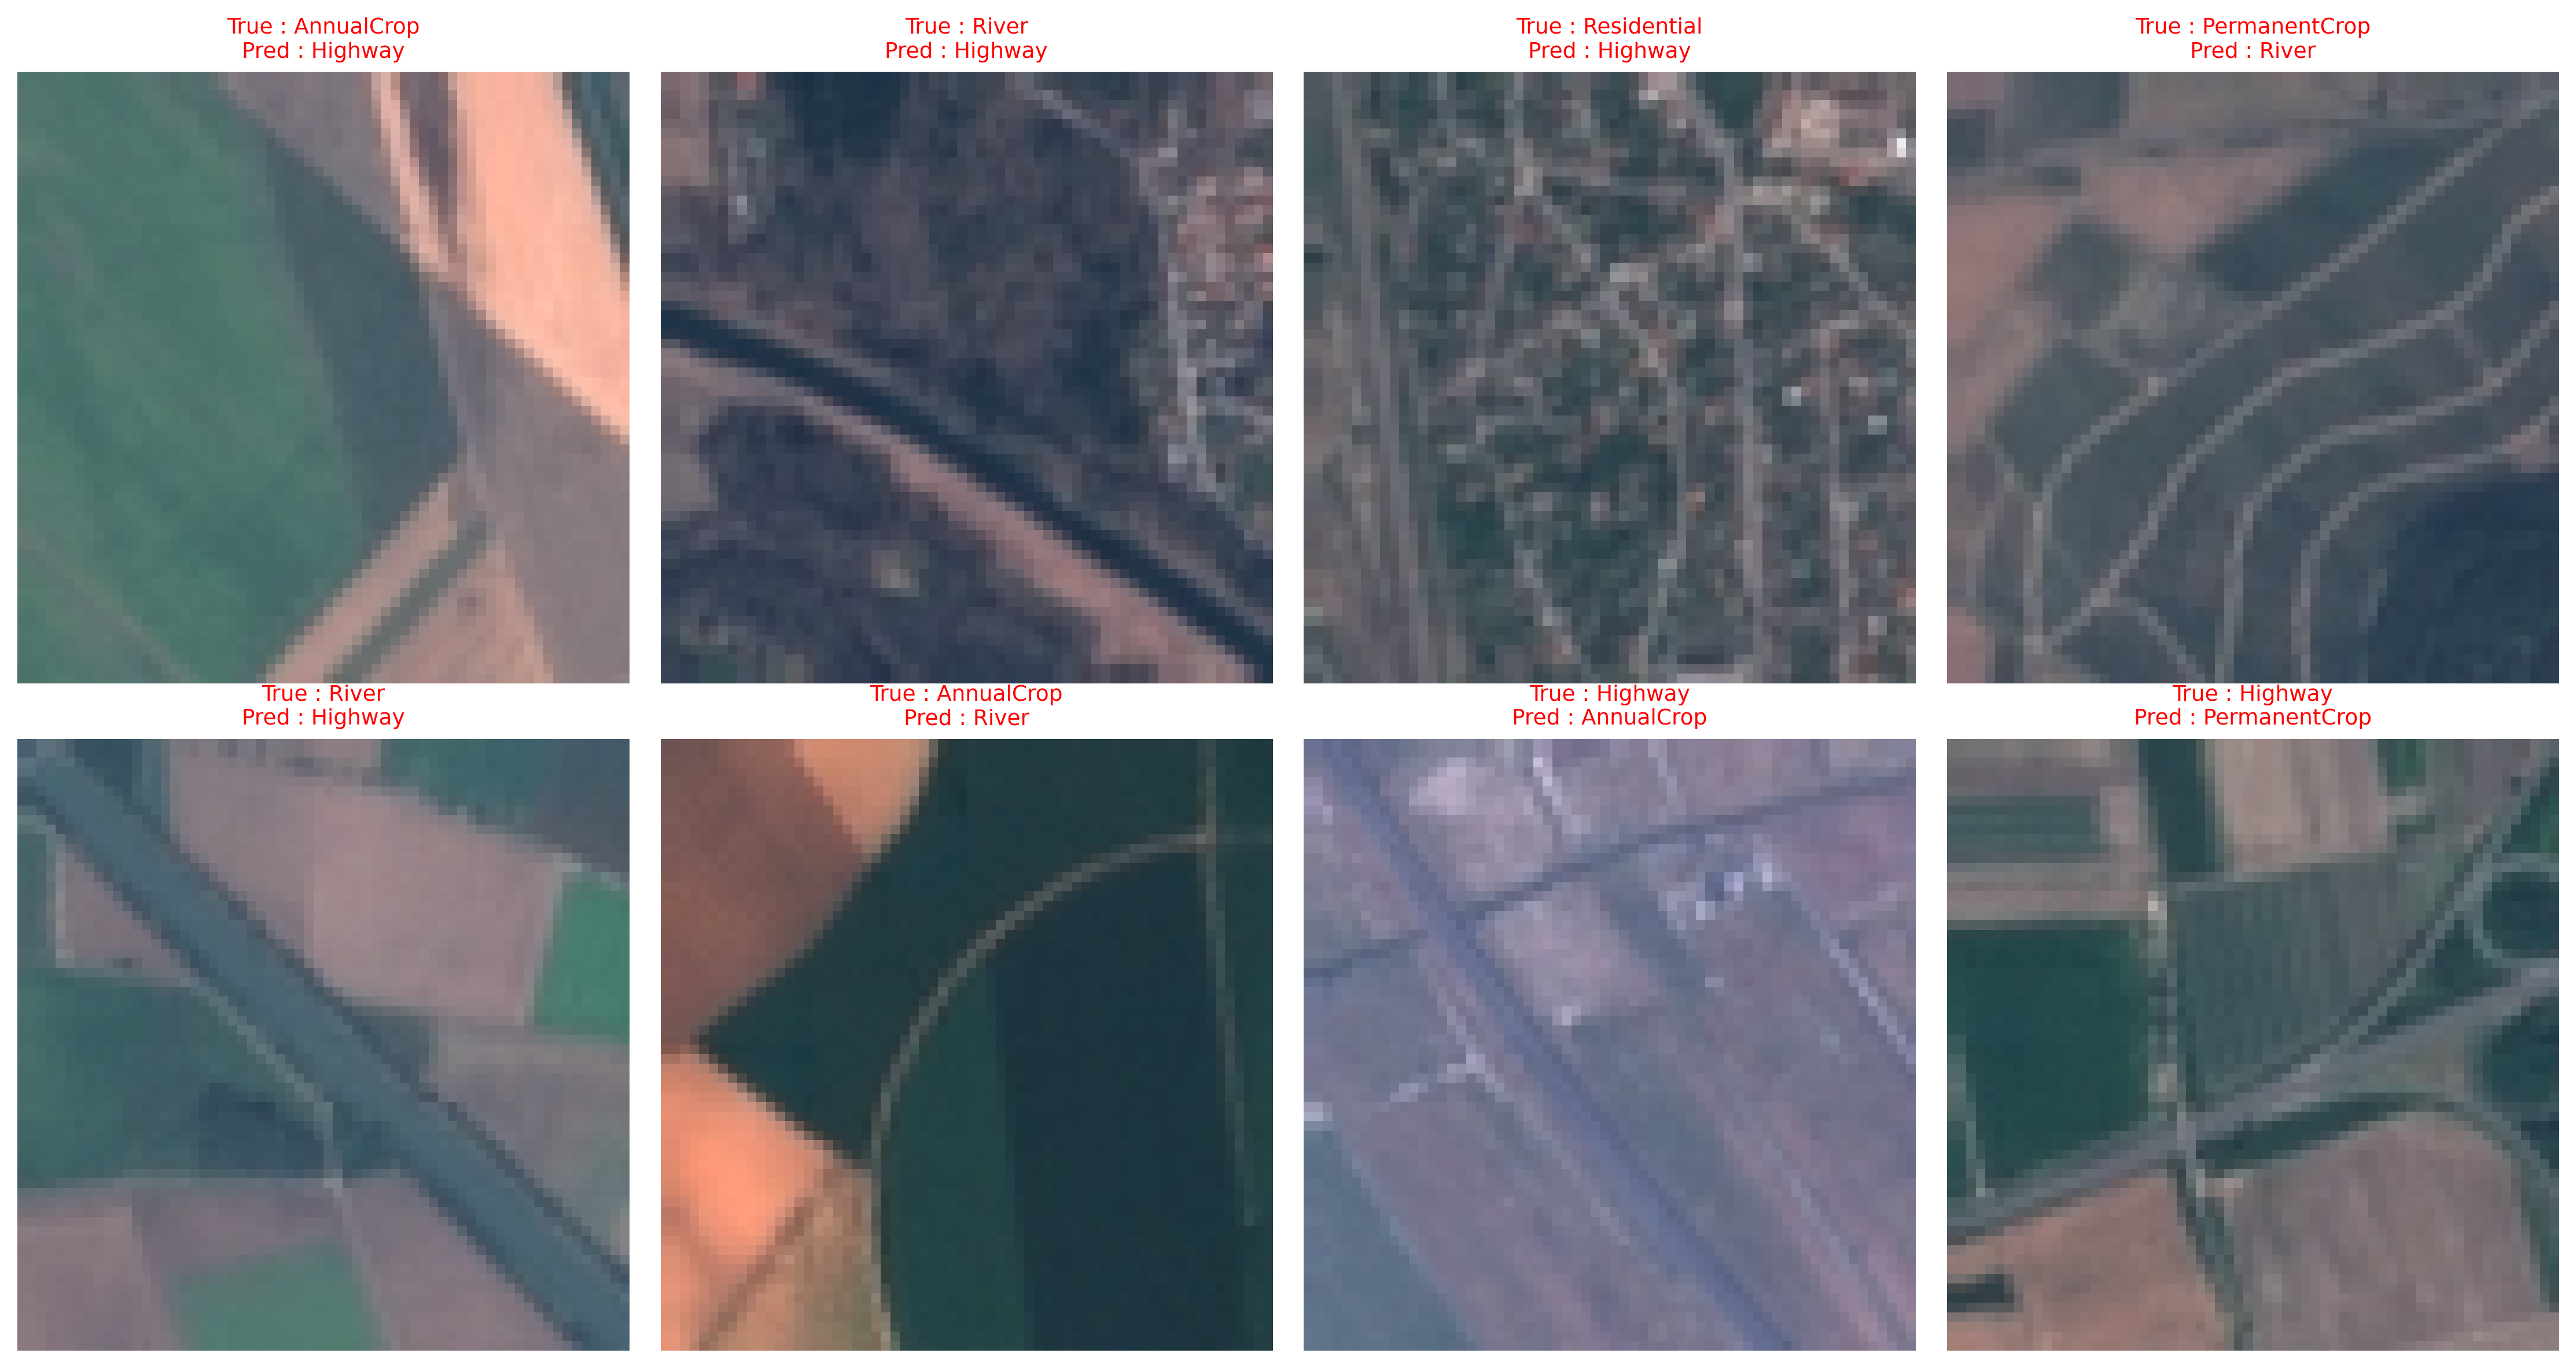

In [67]:
# ============================================================
# Step 11.5 - Misclassified Images
# ============================================================

plt.figure(figsize=(15,8))

for i, idx in enumerate(incorrect_idx[:8]):

    plt.subplot(2,4,i+1)

    plt.imshow(all_images[idx])

    plt.title(
        f"True : {class_names[y_true[idx]]}\n"
        f"Pred : {class_names[y_pred[idx]]}",
        fontsize=9,
        color="red"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "outputs/predictions/misclassified_predictions.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
# ============================================================
# Step 11.6 - Most Confused Classes
# ============================================================

cm = confusion_matrix(y_true, y_pred)

cm_no_diag = cm.copy()

np.fill_diagonal(cm_no_diag, 0)

pairs = []

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm_no_diag[i, j] > 0:
            pairs.append((cm_no_diag[i, j], i, j))

pairs = sorted(pairs, reverse=True)

print("="*70)
print("Top 10 Most Confused Class Pairs")
print("="*70)

for count, true_cls, pred_cls in pairs[:10]:

    print(
        f"{class_names[true_cls]:<25}"
        f" --> "
        f"{class_names[pred_cls]:<25}"
        f"{count}"
    )

Top 10 Most Confused Class Pairs
SeaLake                   --> Forest                   28
River                     --> Highway                  21
PermanentCrop             --> AnnualCrop               21
Pasture                   --> AnnualCrop               16
HerbaceousVegetation      --> Residential              14
Highway                   --> AnnualCrop               13
Highway                   --> River                    12
PermanentCrop             --> HerbaceousVegetation     11
Pasture                   --> HerbaceousVegetation     11
Industrial                --> Residential              11


In [69]:
# ============================================================
# Step 11.7 - Save Error Analysis
# ============================================================

import pandas as pd

error_df = pd.DataFrame(
    [
        {
            "True Class": class_names[t],
            "Predicted Class": class_names[p],
            "Misclassified Images": c
        }
        for c, t, p in pairs
    ]
)

error_df.to_csv(
    "outputs/tables/error_analysis.csv",
    index=False
)

print("Error analysis saved successfully.")

Error analysis saved successfully.


# 12. Inference Time Analysis

Inference time is an important evaluation metric for practical deployment, particularly in real-time or resource-constrained environments. This section measures the average prediction time required by each trained model to classify a single satellite image. The comparison provides insight into the trade-off between computational efficiency and classification performance.

In [70]:
# ============================================================
# Step 12.1 - Measure Inference Time
# ============================================================

import time
import numpy as np

# Get one batch from the test dataset
sample_images, _ = next(iter(test_dataset))

# Use only one image
sample_image = tf.expand_dims(sample_images[0], axis=0)

models = {
    "Custom CNN": custom_cnn_model,
    "MobileNetV2": mobilenet_model,
    "EfficientNetB0": efficientnet_model
}

print("=" * 60)
print("Inference Time Comparison")
print("=" * 60)

results = []

for model_name, model in models.items():

    # Warm-up
    _ = model.predict(sample_image, verbose=0)

    start = time.perf_counter()

    for _ in range(100):
        _ = model.predict(sample_image, verbose=0)

    end = time.perf_counter()

    avg_time = (end - start) / 100

    print(f"{model_name:<20}: {avg_time*1000:.2f} ms/image")

    results.append({
        "Model": model_name,
        "Inference Time (ms/image)": round(avg_time * 1000, 2)
    })

inference_df = pd.DataFrame(results)

display(inference_df)

inference_df.to_csv(
    "outputs/tables/inference_time.csv",
    index=False
)

Inference Time Comparison
Custom CNN          : 78.62 ms/image
MobileNetV2         : 82.06 ms/image
EfficientNetB0      : 85.87 ms/image


,Model,Inference Time (ms/image)
0,Custom CNN,78.62
1,MobileNetV2,82.06
2,EfficientNetB0,85.87


# 13. Discussion

The performance of the three deep learning models is compared using quantitative evaluation metrics, including classification accuracy, loss, confusion matrices, classification reports, ROC curves, and error analysis. The strengths and limitations of each architecture are discussed to explain the observed differences in classification performance and their suitability for satellite image classification tasks.

# 14. Conclusion

This project demonstrated the effectiveness of deep learning for satellite land-use image classification using the EuroSAT RGB dataset. Three different architectures, including a custom CNN, MobileNetV2, and EfficientNetB0, were implemented and systematically evaluated. Experimental results showed that EfficientNetB0 achieved the highest classification performance, highlighting the advantages of transfer learning for remote sensing applications. Future work may explore larger EfficientNet variants, Vision Transformers, explainable AI techniques, and additional satellite datasets to further improve classification accuracy and model interpretability.